# **Problem Statement**

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# **Installing and Importing the necessary libraries**

In [1]:
# Installing the libraries with the specified version
# !pip install --no-deps tensorflow==2.19.0 scikit-learn==1.6.1 matplotlib===3.10.0 seaborn==0.13.2 numpy==2.0.2 pandas==2.2.2 -q --user --no-warn-script-location
# !pip install imblearn

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [2]:
# Libraries for data manipulation, analysis and scientific computing
import pandas as pd
import numpy as np

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Library for time related functions
import time

# For splitting datasets into training and testing sets.
from sklearn.model_selection import train_test_split
# Tools for data preprocessing including label encoding, one-hot encoding, and standard scaling
from sklearn.preprocessing import LabelEncoder, OneHotEncoder,StandardScaler
# Imports a class for imputing missing values in datasets.
from sklearn.impute import SimpleImputer

# To oversample data
from imblearn.over_sampling import SMOTE

# Imports for evaluating the performance of machine learning models
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    classification_report
)

# Imports the tensorflow, keras and layers.
import tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras import backend


# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# **Loading the Data**

In [3]:
# uncomment and run the following lines for Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
# Reading the data from csv files and assigning it to a DataFrame .

original_train_data = pd.read_csv('Train.csv')
original_test_data = pd.read_csv('Test.csv')

# Creating work copies of the Dataframes.

df = original_train_data.copy()
df_test = original_test_data.copy()

In [5]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) *numpy* seed that influences operations that involve randomess like shuffling data, initializing weights or dropout layers.
# 2) backend random seed that influences operations within keras itself.
# 3) *Python* random seed.
keras.utils.set_random_seed(812)

# Call function so that TensorFlow attempts to make operations more deterministic.
tf.config.experimental.enable_op_determinism()

# **Data Overview**

In [6]:
# Shape of the train data.
df.shape

(20000, 41)

In [7]:
# Shape of the test data.
df_test.shape

(5000, 41)

**Observations:**
* The train set has 20000 rows and 41 columns.
* The test set has 5000 rows and 41 columns.

## Displaying the first few rows of the dataset.

In [8]:
# Let's view the first 5 rows of the train data.
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,-5.714719,0.735893,0.981251,1.417884,-3.375815,-3.047303,0.306194,2.914097,2.269979,4.394876,-2.388299,0.646388,-1.190508,3.132986,0.665277,-2.510846,-0.036744,0.726218,-3.982187,-1.072638,1.667098,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,1.914465,-0.951458,-1.255259,-2.706522,0.193223,-4.769379,-2.205319,0.907716,0.756894,-5.833678,-3.065122,1.596647,-1.757311,1.766444,-0.267098,3.625036,1.500346,-0.585712,0.783034,-0.201217,0.024883,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,-0.770673,1.106718,1.144261,0.943301,-3.163804,-4.247825,-4.038909,3.688534,3.311196,1.059002,-2.143026,1.650120,-1.660592,1.679910,-0.450782,-4.550695,3.738779,1.134404,-2.033531,0.840839,-1.600395,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,-3.053023,0.459719,2.704527,-0.636086,-0.453717,-3.174046,-3.404347,-1.281536,1.582104,-1.951778,-3.516555,-1.206011,-5.627854,-1.817653,2.124142,5.294642,4.748137,-2.308536,-3.962977,-6.028730,4.948770,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,1.998347,4.723757,0.709113,-1.989432,-2.632684,4.184447,2.245356,3.734452,-6.312766,-5.379918,-0.886667,2.061694,9.445586,4.489976,-3.945144,4.582065,-8.780422,-3.382967,5.106507,6.787513,2.044184,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


In [9]:
#Viewing first 5 rows of the test data.
df_test.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613489,-3.819640,2.202302,1.300420,-1.184929,-4.495964,-1.835817,4.722989,1.206140,-0.341909,-5.122874,1.017021,4.818549,3.269001,-2.984330,1.387370,2.032002,-0.511587,-1.023069,7.338733,-2.242244,0.155489,2.053786,-2.772273,1.851369,-1.788696,-0.277282,-1.255143,-3.832886,-1.504542,1.586765,2.291204,-5.411388,0.870073,0.574479,4.157191,1.428093,-10.511342,0.454664,-1.448363,0
1,0.389608,-0.512341,0.527053,-2.576776,-1.016766,2.235112,-0.441301,-4.405744,-0.332869,1.966794,1.796544,0.410490,0.638328,-1.389600,-1.883410,-5.017922,-3.827238,2.418060,1.762285,-3.242297,-3.192960,1.857454,-1.707954,0.633444,-0.587898,0.083683,3.013935,-0.182309,0.223917,0.865228,-1.782158,-2.474936,2.493582,0.315165,2.059288,0.683859,-0.485452,5.128350,1.720744,-1.488235,0
2,-0.874861,-0.640632,4.084202,-1.590454,0.525855,-1.957592,-0.695367,1.347309,-1.732348,0.466500,-4.928214,3.565070,-0.449329,-0.656246,-0.166537,-1.630207,2.291865,2.396492,0.601278,1.793534,-2.120238,0.481968,-0.840707,1.790197,1.874395,0.363930,-0.169063,-0.483832,-2.118982,-2.156586,2.907291,-1.318888,-2.997464,0.459664,0.619774,5.631504,1.323512,-1.752154,1.808302,1.675748,0
3,0.238384,1.458607,4.014528,2.534478,1.196987,-3.117330,-0.924035,0.269493,1.322436,0.702345,-5.578345,-0.850662,2.590525,0.767418,-2.390809,-2.341961,0.571875,-0.933751,0.508677,1.210715,-3.259524,0.104587,-0.658875,1.498107,1.100305,4.142988,-0.248446,-1.136516,-5.355810,-4.545931,3.808667,3.517918,-3.074085,-0.284220,0.954576,3.029331,-1.367198,-3.412140,0.906000,-2.450889,0
4,5.828225,2.768260,-1.234530,2.809264,-1.641648,-1.406698,0.568643,0.965043,1.918379,-2.774855,-0.530016,1.374544,-0.650941,-1.679466,-0.379220,-4.443143,3.893857,-0.607640,2.944931,0.367233,-5.789081,4.597528,4.450264,3.224941,0.396701,0.247765,-2.362047,1.079378,-0.473076,2.242810,-3.591421,1.773841,-1.501573,-2.226702,4.776830,-6.559698,-0.805551,-0.276007,-3.858207,-0.537694,0


**Observations:**
* Both datasets have loaded properly.

## Checking the data types of the columns in the dataset.

In [10]:
# View the data types of the columns in the train data.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22  V23     2

In [11]:
# View the data types of the columns in the test data.
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      4995 non-null   float64
 1   V2      4994 non-null   float64
 2   V3      5000 non-null   float64
 3   V4      5000 non-null   float64
 4   V5      5000 non-null   float64
 5   V6      5000 non-null   float64
 6   V7      5000 non-null   float64
 7   V8      5000 non-null   float64
 8   V9      5000 non-null   float64
 9   V10     5000 non-null   float64
 10  V11     5000 non-null   float64
 11  V12     5000 non-null   float64
 12  V13     5000 non-null   float64
 13  V14     5000 non-null   float64
 14  V15     5000 non-null   float64
 15  V16     5000 non-null   float64
 16  V17     5000 non-null   float64
 17  V18     5000 non-null   float64
 18  V19     5000 non-null   float64
 19  V20     5000 non-null   float64
 20  V21     5000 non-null   float64
 21  V22     5000 non-null   float64
 22  V23     500

Convert the 'Target' column to float for compatibility with neural network operations.

In [12]:
# Convert the 'Target' column to float in train set.
df['Target'] = df['Target'].astype(float)

In [13]:
# Convert the 'Target' column to float in test set.
df_test['Target'] = df_test['Target'].astype(float)

## Checking for duplicate values.

In [14]:
# Let's check for duplicate values in the train data.
df.duplicated().sum()

np.int64(0)

**Observations:**
* There are no duplicated values in the training dataset.

## Checking for missing values.

In [15]:
# Let's check for missing values in the train data.
df.isnull().sum()

V1        18
V2        18
V3         0
V4         0
V5         0
V6         0
V7         0
V8         0
V9         0
V10        0
V11        0
V12        0
V13        0
V14        0
V15        0
V16        0
V17        0
V18        0
V19        0
V20        0
V21        0
V22        0
V23        0
V24        0
V25        0
V26        0
V27        0
V28        0
V29        0
V30        0
V31        0
V32        0
V33        0
V34        0
V35        0
V36        0
V37        0
V38        0
V39        0
V40        0
Target     0
dtype: int64

In [16]:
# Let's check for missing values in the test data.
df_test.isnull().sum() #

V1        5
V2        6
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
V29       0
V30       0
V31       0
V32       0
V33       0
V34       0
V35       0
V36       0
V37       0
V38       0
V39       0
V40       0
Target    0
dtype: int64

**Observations:**
* There are missing values in V1 and V2 in both sets.

In [17]:
# Check the distinct categories in 'Target' column of train data.
print("Train set categories and value counts")
print("Number of unique categories:", df["Target"].nunique(),"\n")
print("Value counts for each category:\n", df["Target"].value_counts(), "\n")
print("Percentage of each category:\n", df["Target"].value_counts()/df["Target"].shape[0], "\n")

print("-" * 50)

# Check the distinct categories in 'Target' column of test data.
print("Test set categories and value counts")
print("Number of unique categories:", df_test["Target"].nunique(),"\n")
print("Value counts for each category:\n", df_test["Target"].value_counts(), "\n")
print("Percentage of each category:\n", df_test["Target"].value_counts()/df_test["Target"].shape[0], "\n")

Train set categories and value counts
Number of unique categories: 2 

Value counts for each category:
 Target
0.0    18890
1.0     1110
Name: count, dtype: int64 

Percentage of each category:
 Target
0.0    0.9445
1.0    0.0555
Name: count, dtype: float64 

--------------------------------------------------
Test set categories and value counts
Number of unique categories: 2 

Value counts for each category:
 Target
0.0    4718
1.0     282
Name: count, dtype: int64 

Percentage of each category:
 Target
0.0    0.9436
1.0    0.0564
Name: count, dtype: float64 



**Observations:**
* The Target column was of integer type which was converted to floating type.
* Percentage of each category in 'Target' column **shows data imbalance**. Approximately 94.45% of the cases represent "No failure" (Target = 0), while about 5.5% represent "Failure" (Target = 1). Same imbalance is in test dataset.

## Statistical summaries of the datasets.

In [18]:
# Let's view the statistical summary of the numerical columns in the train data.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,19982.0,-0.271996,3.441625,-11.876451,-2.737146,-0.747917,1.840112,15.493002
V2,19982.0,0.440430,3.150784,-12.319951,-1.640674,0.471536,2.543967,13.089269
V3,20000.0,2.484699,3.388963,-10.708139,0.206860,2.255786,4.566165,17.090919
V4,20000.0,-0.083152,3.431595,-15.082052,-2.347660,-0.135241,2.130615,13.236381
V5,20000.0,-0.053752,2.104801,-8.603361,-1.535607,-0.101952,1.340480,8.133797
V6,20000.0,-0.995443,2.040970,-10.227147,-2.347238,-1.000515,0.380330,6.975847
V7,20000.0,-0.879325,1.761626,-7.949681,-2.030926,-0.917179,0.223695,8.006091
V8,20000.0,-0.548195,3.295756,-15.657561,-2.642665,-0.389085,1.722965,11.679495
V9,20000.0,-0.016808,2.160568,-8.596313,-1.494973,-0.067597,1.409203,8.137580
V10,20000.0,-0.012998,2.193201,-9.853957,-1.411212,0.100973,1.477045,8.108472


In [19]:
# Let's view the statistical summary of the numerical columns in the test data.
df_test.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,4995.0,-0.277622,3.466280,-12.381696,-2.743691,-0.764767,1.831313,13.504352
V2,4994.0,0.397928,3.139562,-10.716179,-1.649211,0.427369,2.444486,14.079073
V3,5000.0,2.551787,3.326607,-9.237940,0.314931,2.260428,4.587000,15.314503
V4,5000.0,-0.048943,3.413937,-14.682446,-2.292694,-0.145753,2.166468,12.140157
V5,5000.0,-0.080120,2.110870,-7.711569,-1.615238,-0.131890,1.341197,7.672835
V6,5000.0,-1.042138,2.005444,-8.924196,-2.368853,-1.048571,0.307555,5.067685
V7,5000.0,-0.907922,1.769017,-8.124230,-2.054259,-0.939695,0.212228,7.616182
V8,5000.0,-0.574592,3.331911,-12.252731,-2.642088,-0.357943,1.712896,10.414722
V9,5000.0,0.030121,2.174139,-6.785495,-1.455712,-0.079891,1.449548,8.850720
V10,5000.0,0.018524,2.145437,-8.170956,-1.353320,0.166292,1.511248,6.598728


**Observations:**
* Summary shows a wide range of values and varying standard deviations across the predictor variables (V1-V40) for both sets.
* Normalization is recommended to improve convergence and performance.

# **Exploratory Data Analysis**

## Univariate analysis.

In [20]:
# Function to plot histogram and box plot along the same scale.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None, title=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show density curve (default False)
    bins: number of bins for histogram (default None)
    title: title of plot (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )

    # Add title to the figure if provided.
    if title:
        f2.suptitle(title, y=0.9) # Use suptitle for a title over all subplots.

    # creating the 2 subplots.
    # boxplot will be created and a triangle will indicate the mean value of the column.
    sns.boxplot(
        data= data, x= feature, ax= ax_box2, showmeans=True, color="violet"
    )

    # For histogram.
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=df, x=feature, kde=kde, ax=ax_hist2
    )

    # Add mean to the histogram.
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--", label = 'Mean'
    )
    # Add median to the histogram.
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-", label = 'Median'
    )
    ax_hist2.legend()

### Create graphs for variables V1 to V40 and Target.

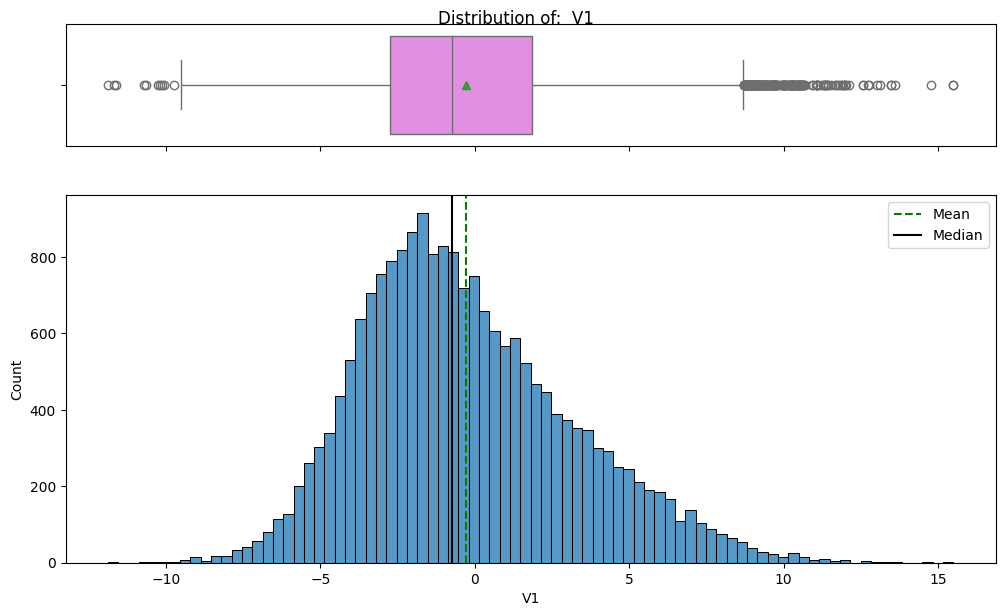

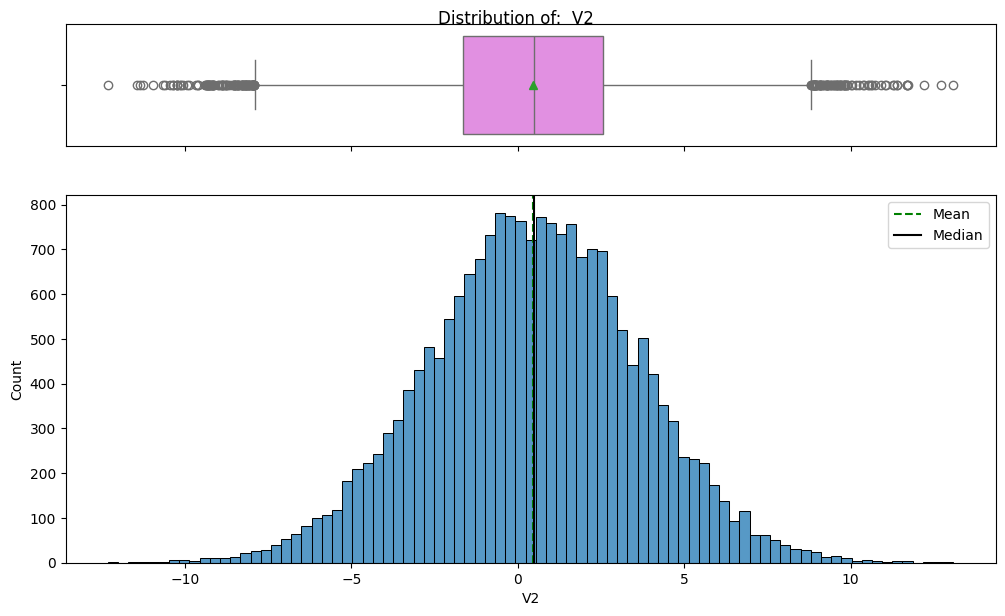

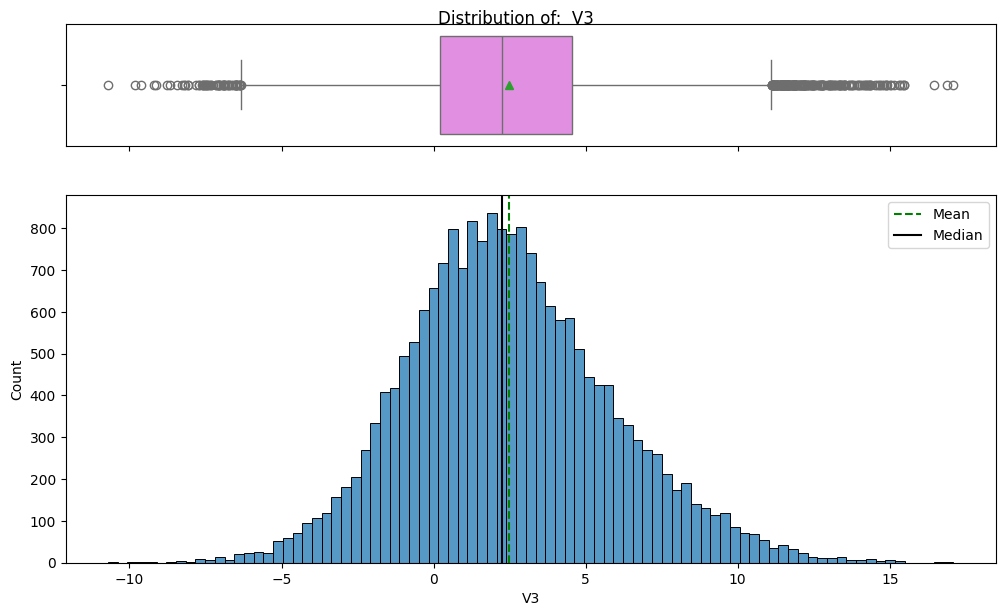

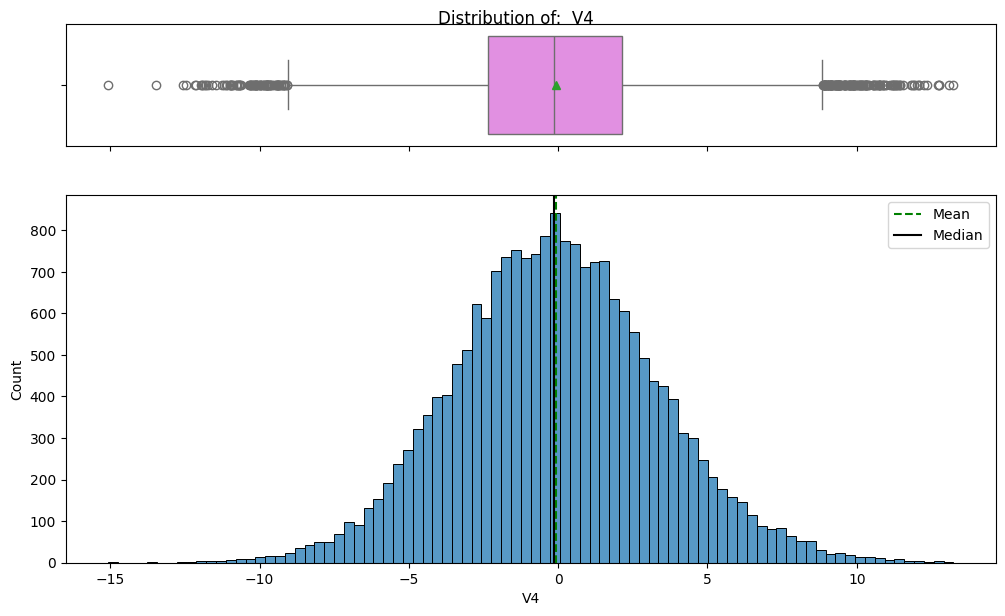

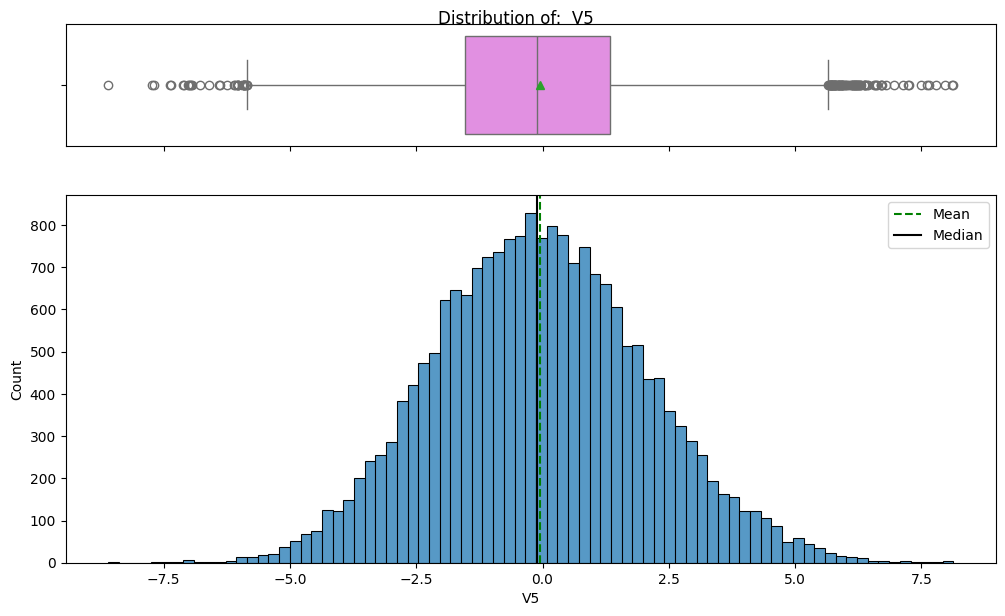

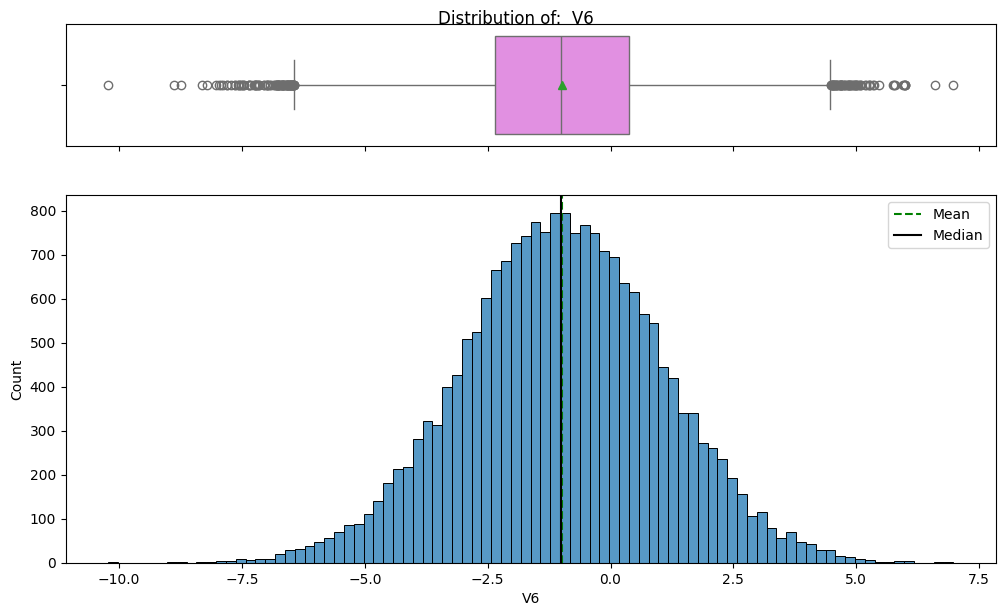

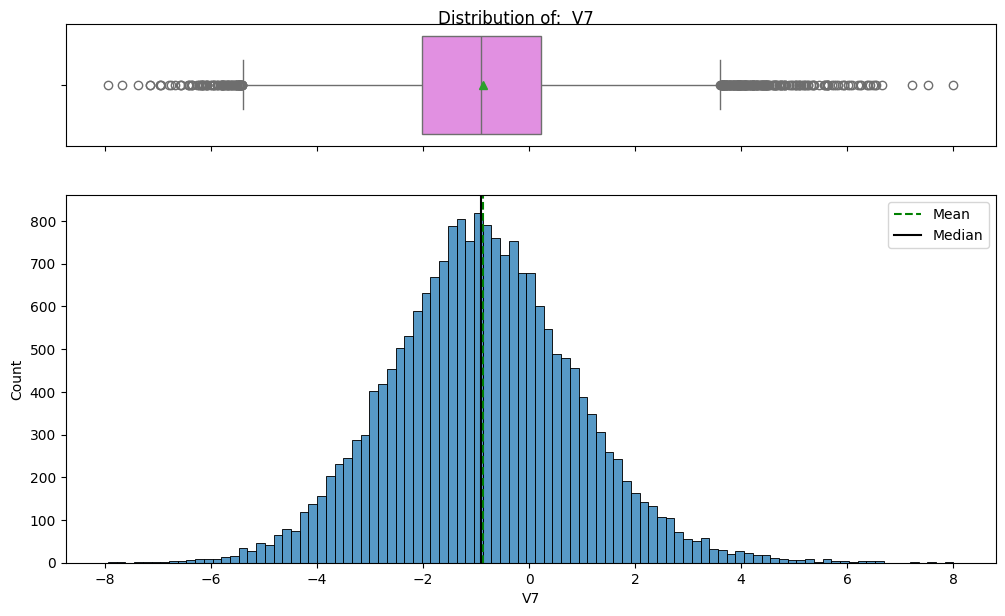

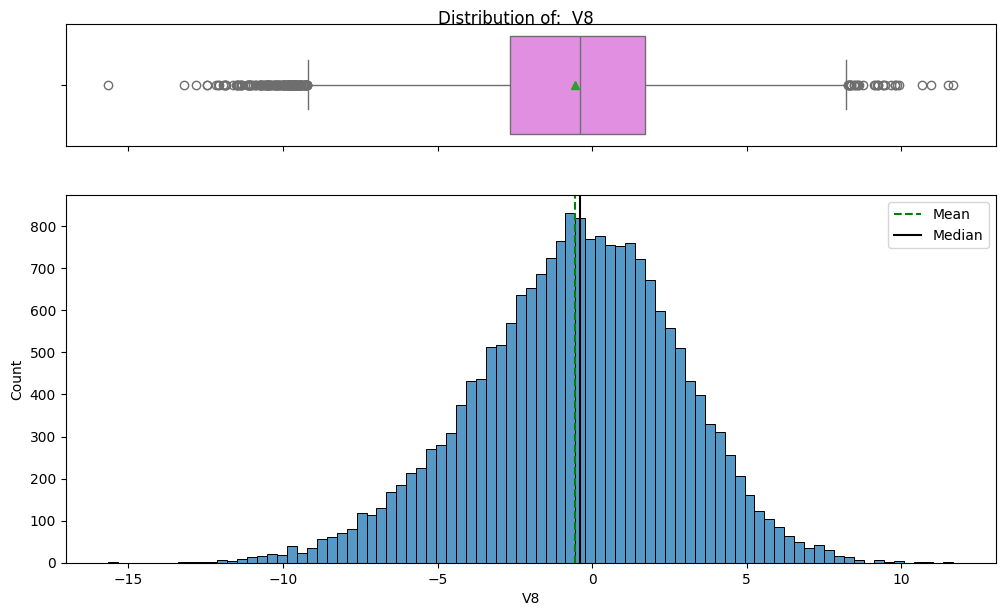

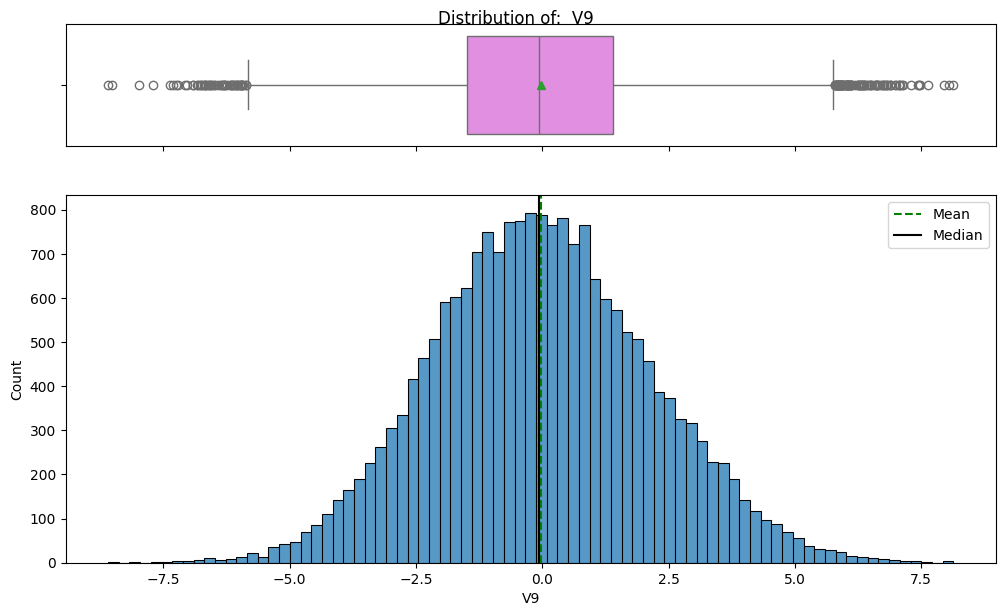

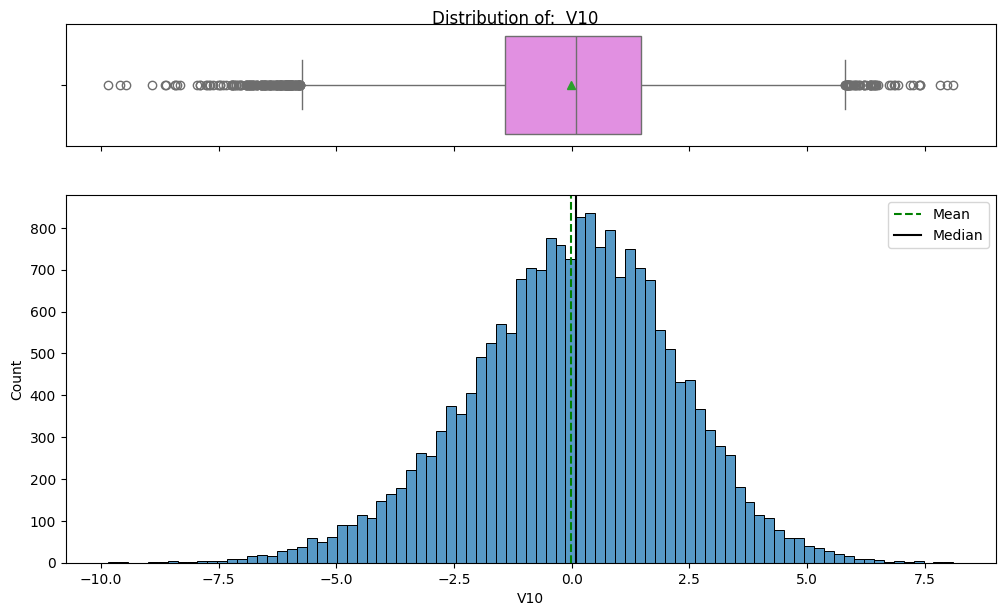

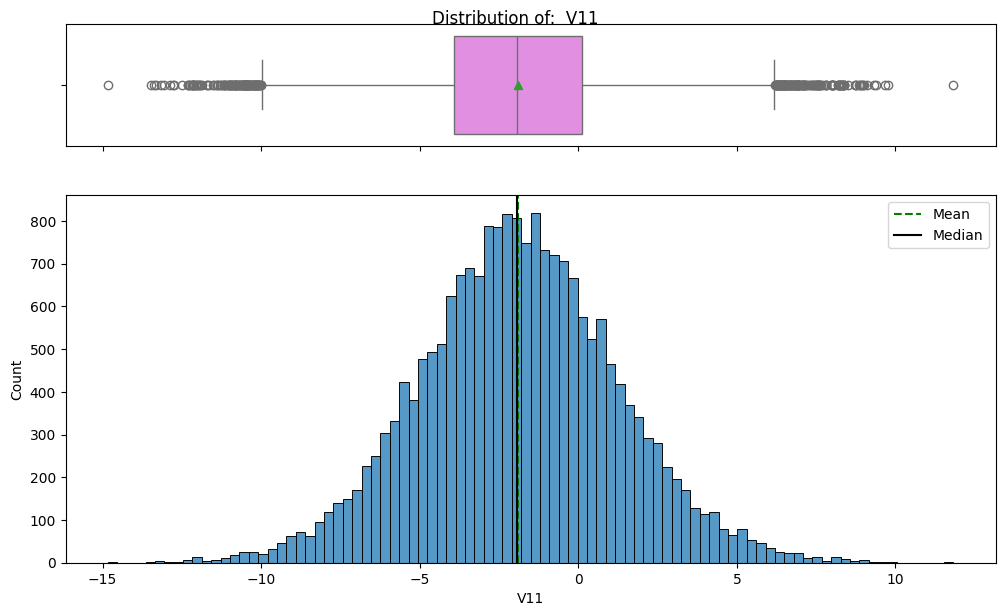

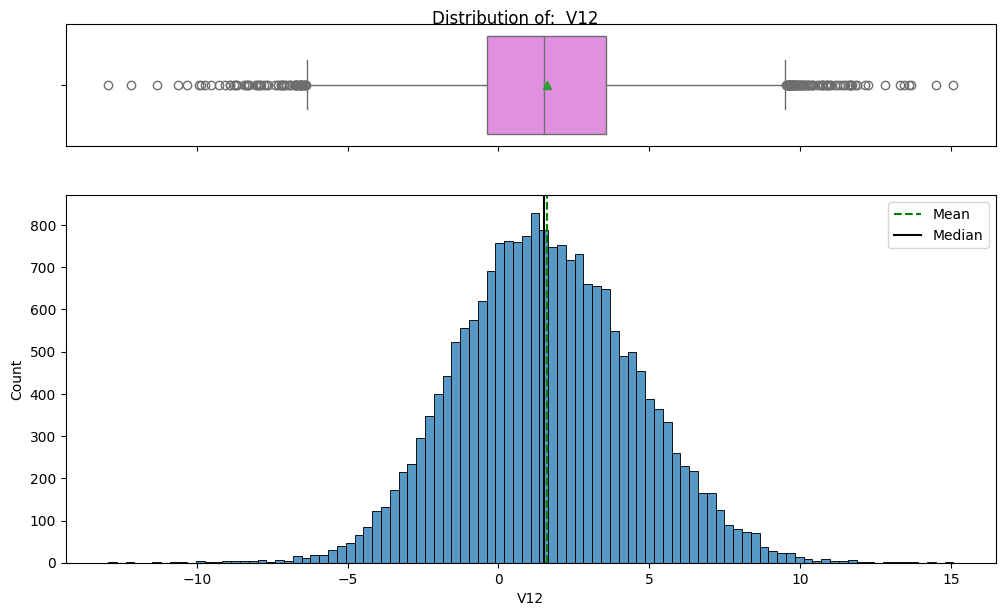

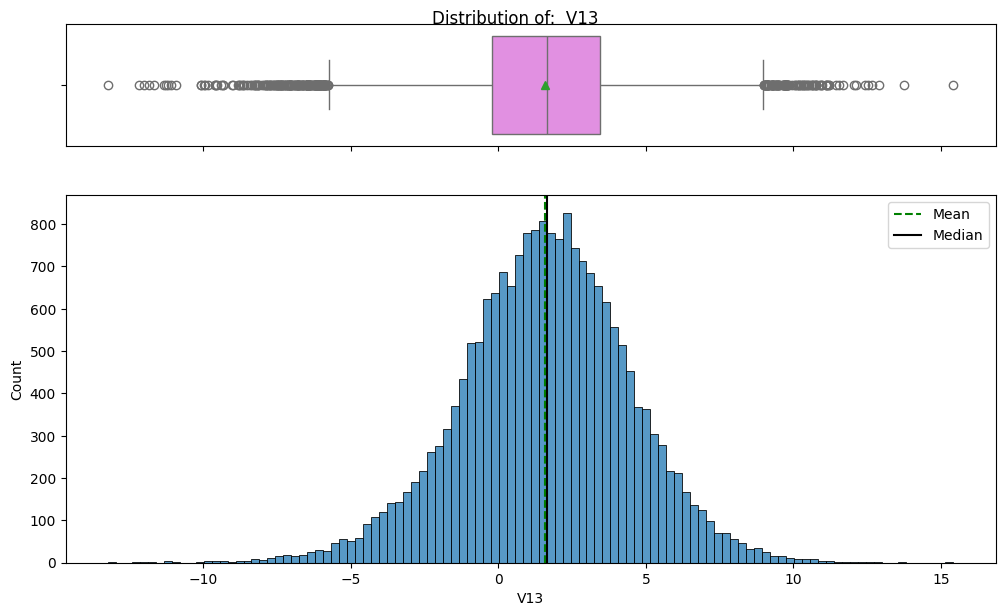

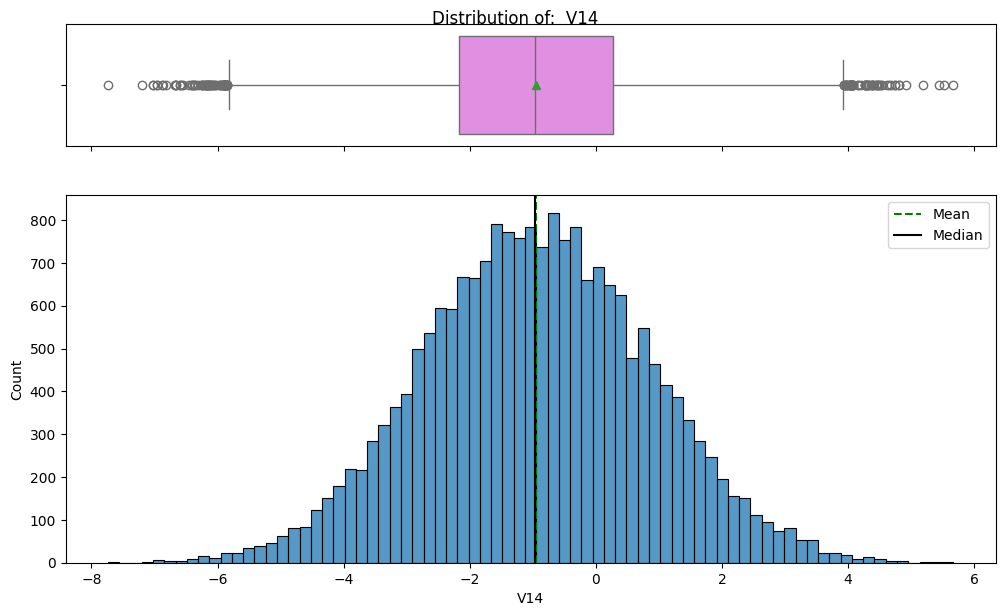

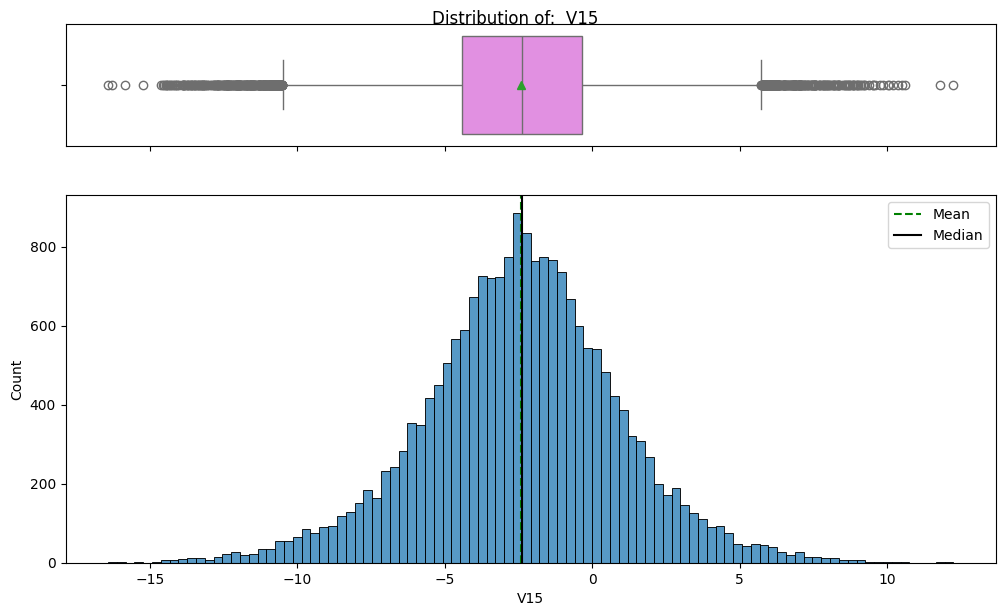

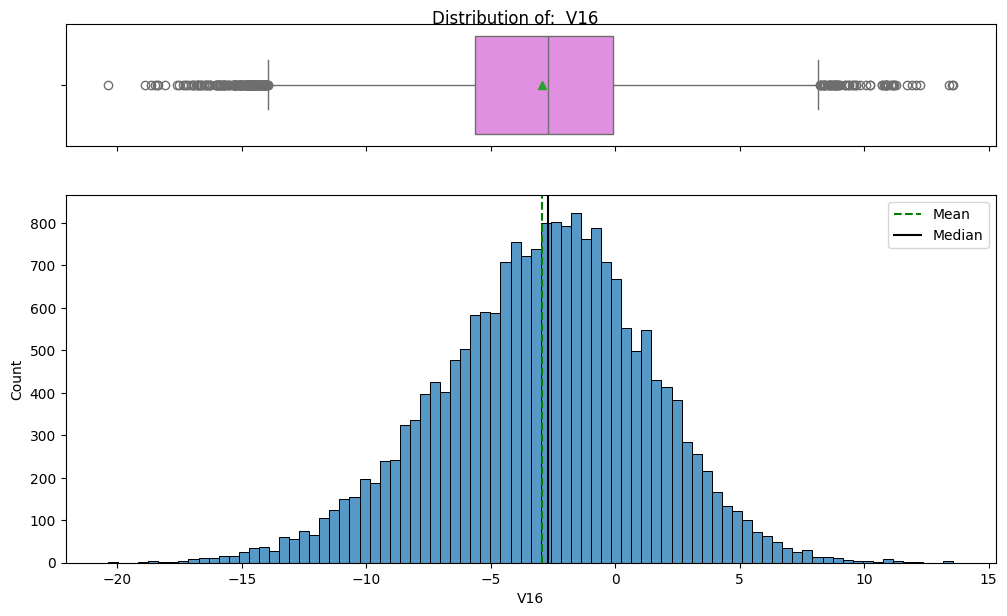

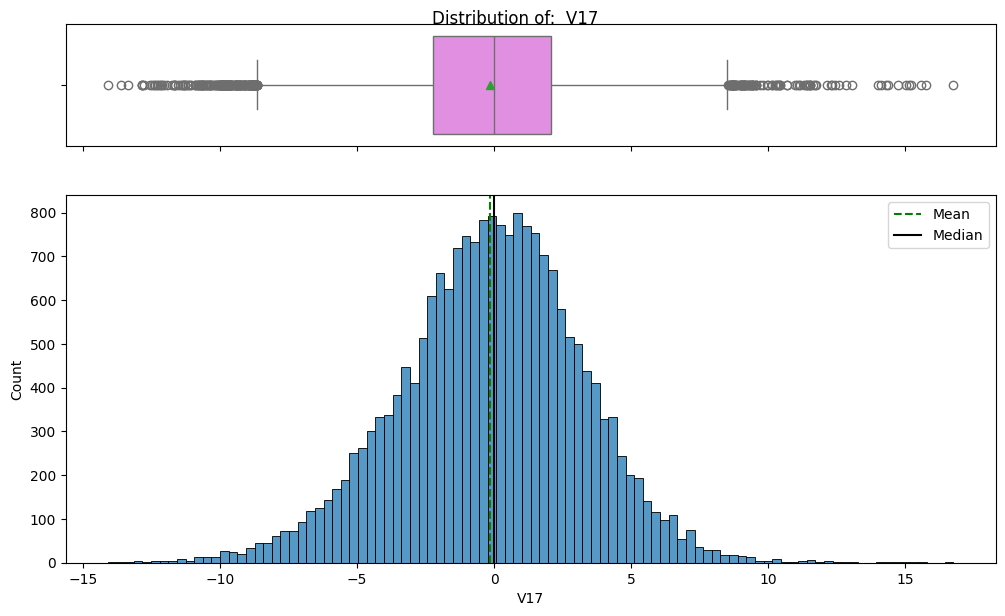

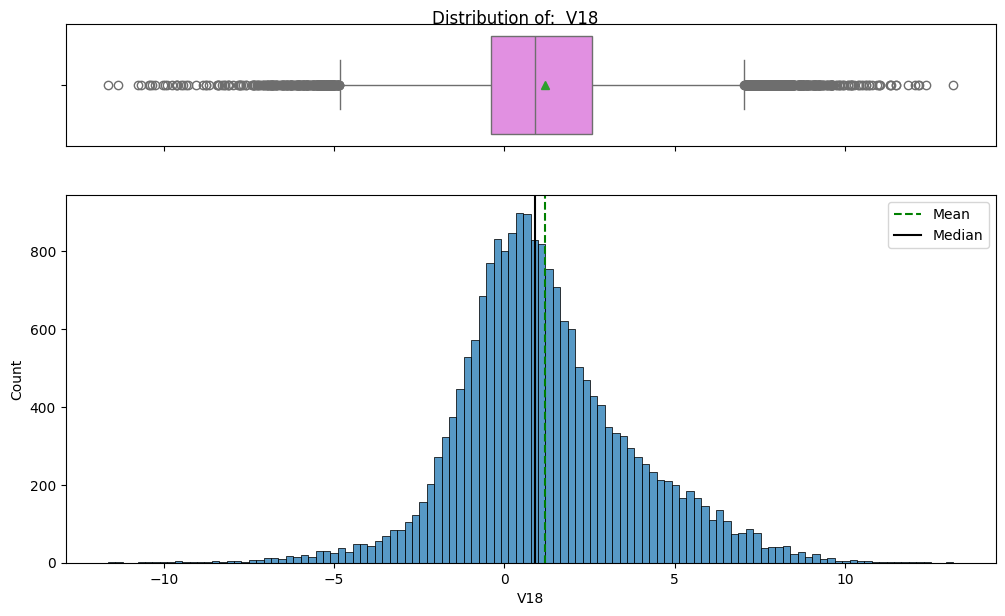

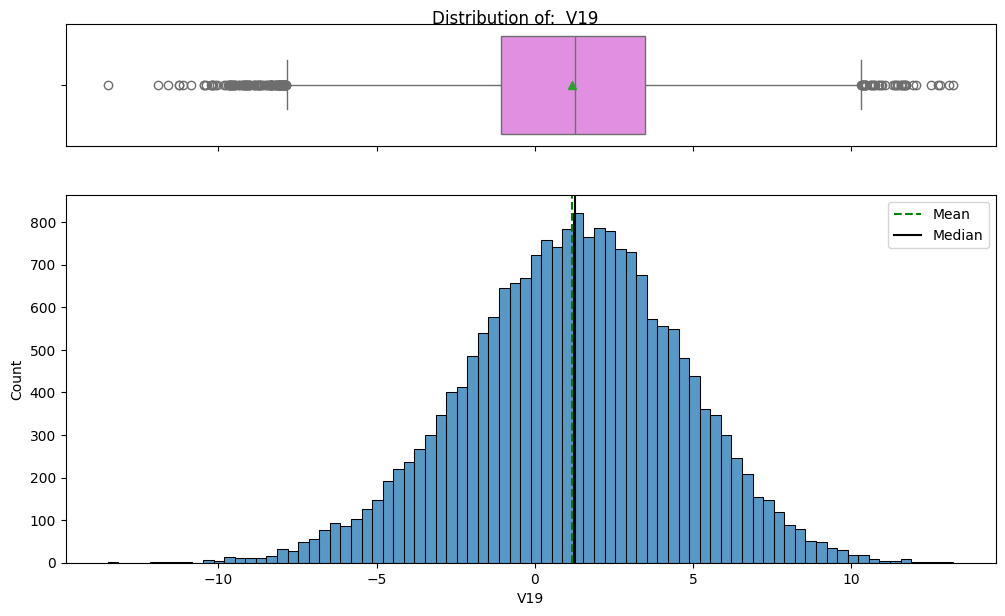

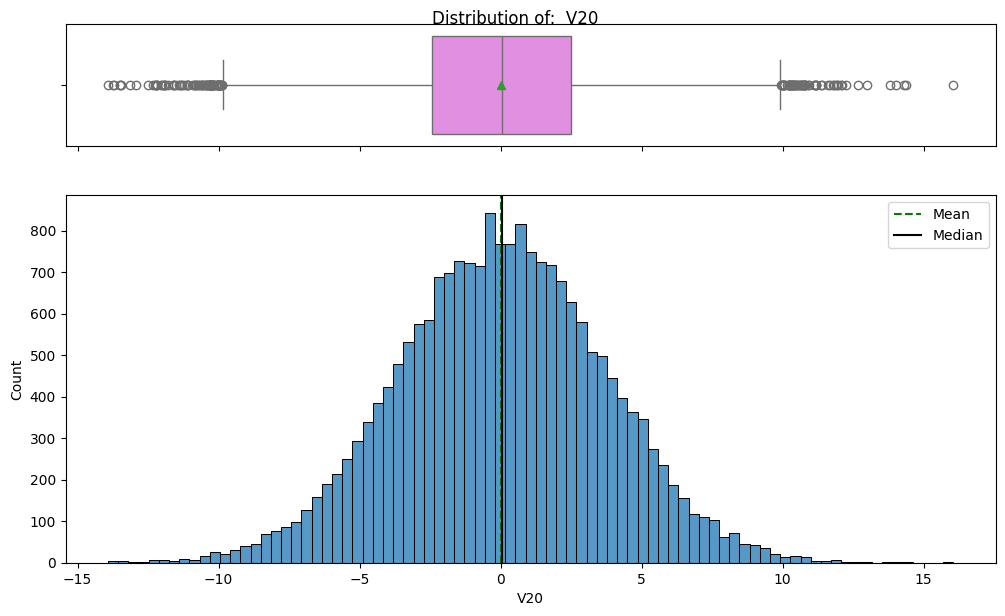

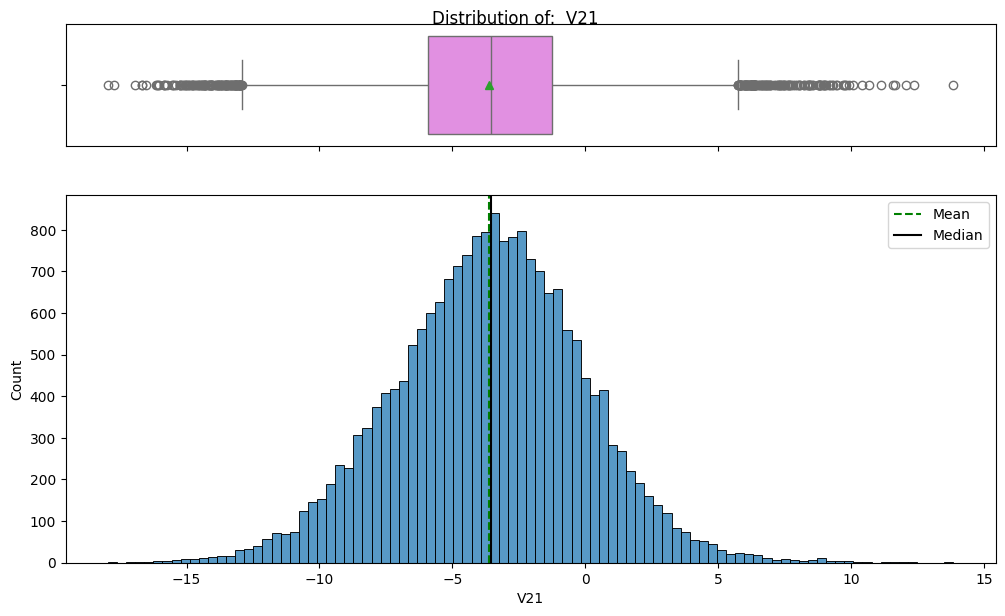

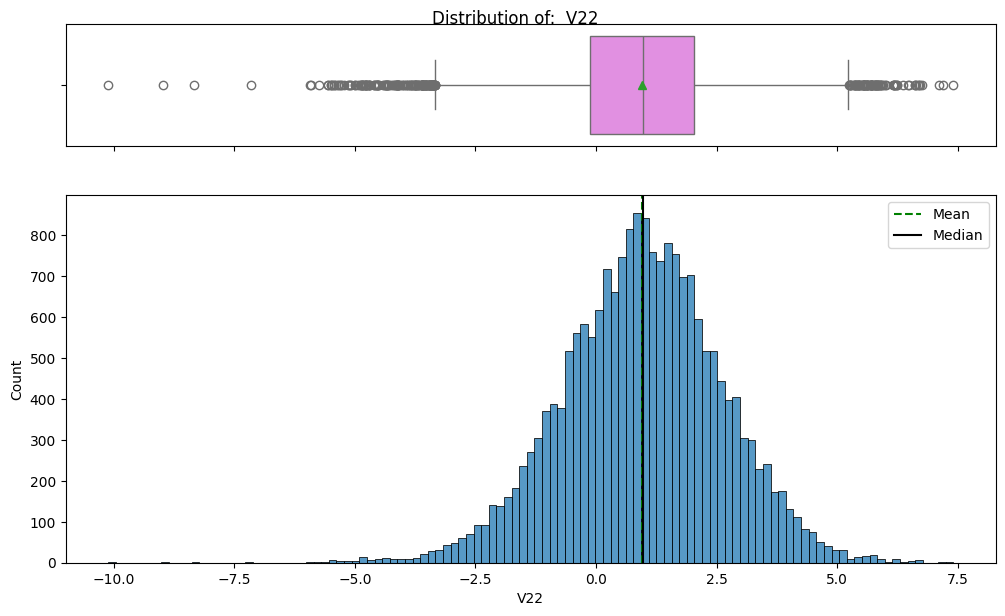

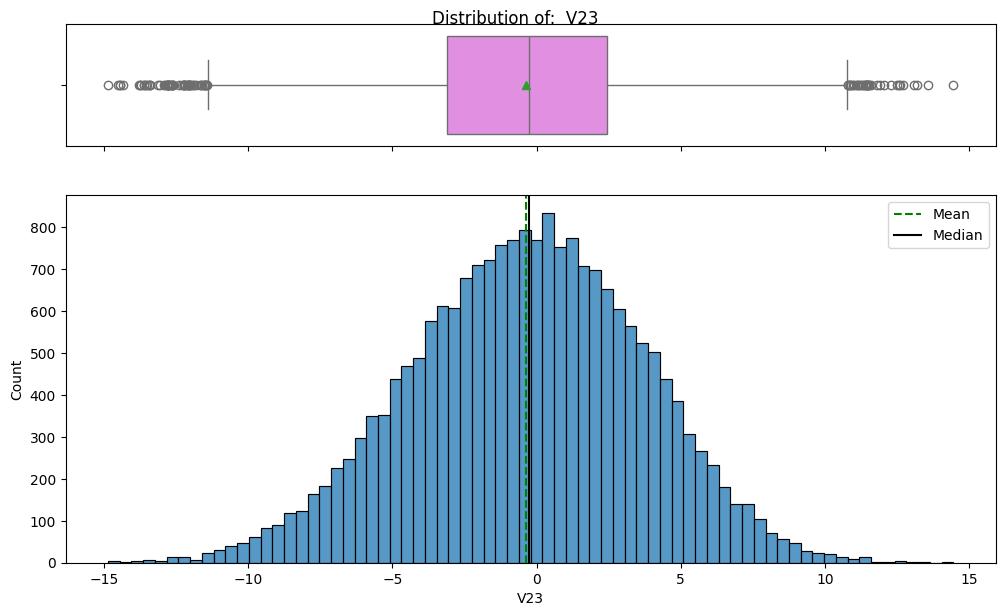

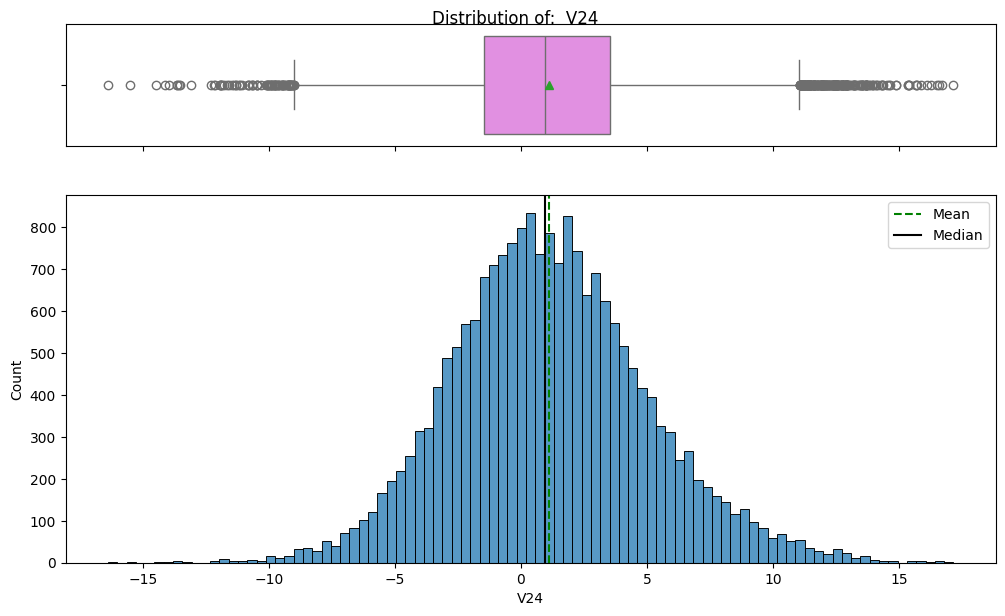

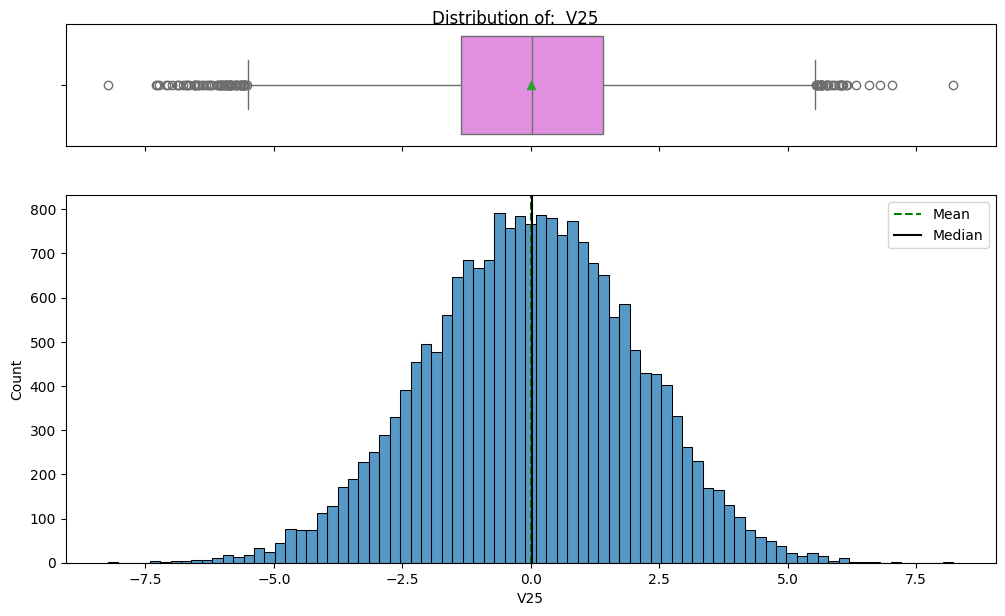

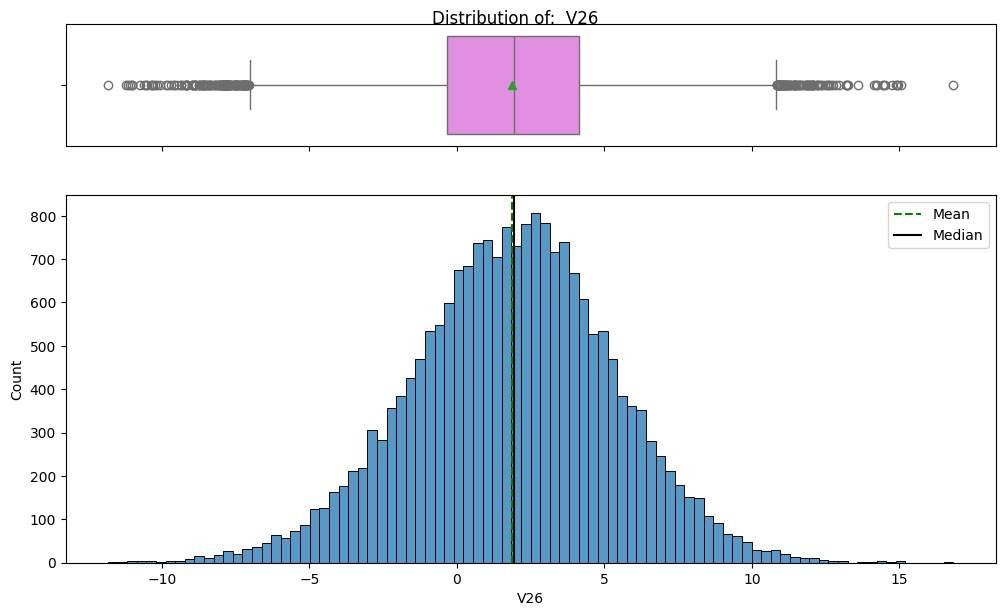

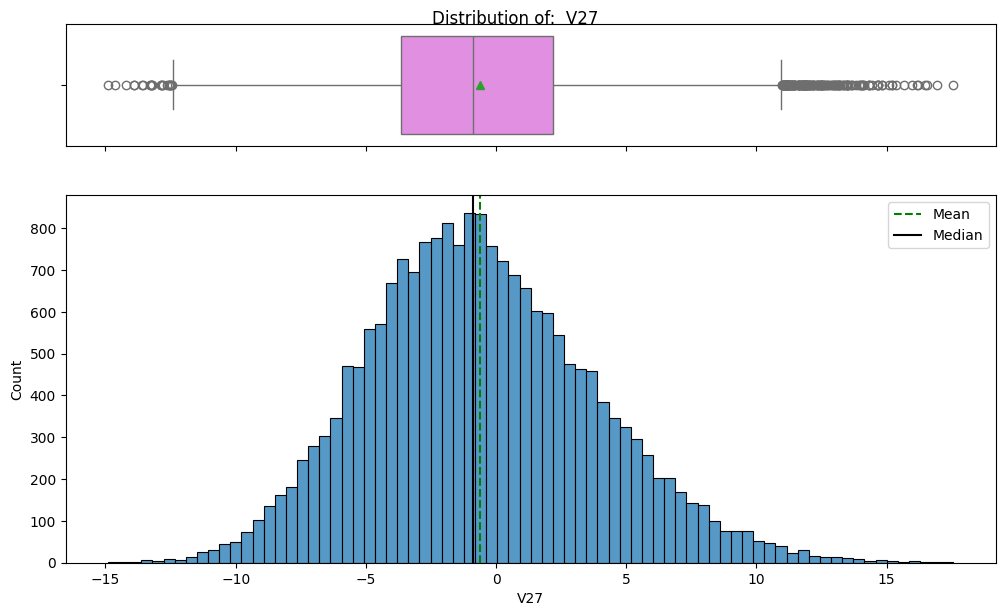

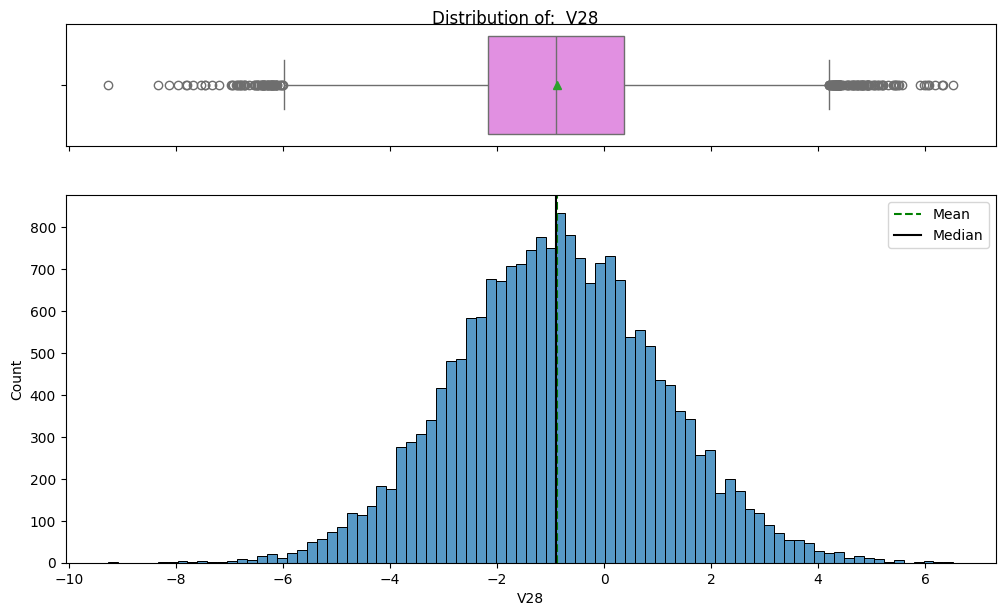

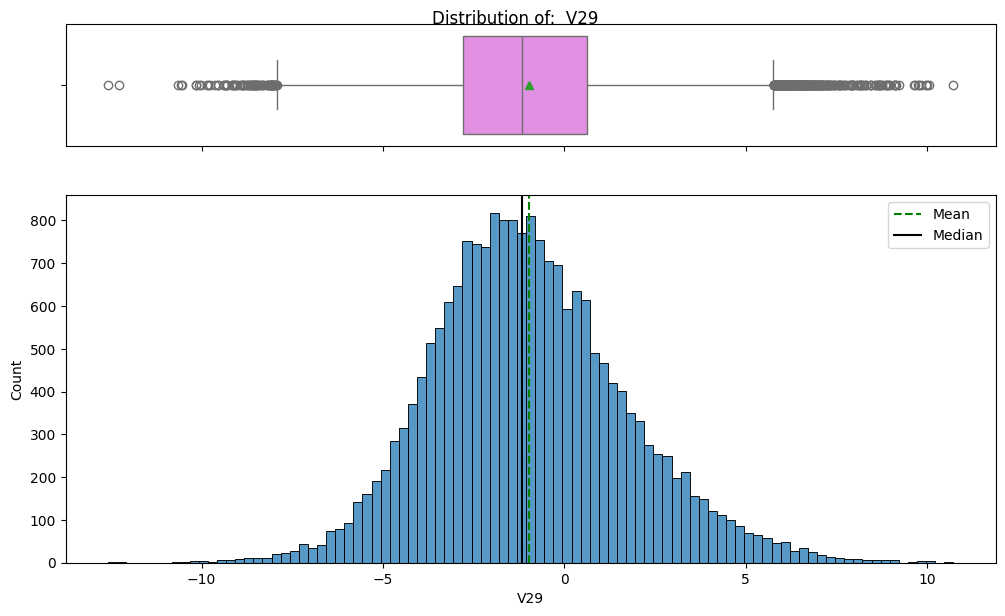

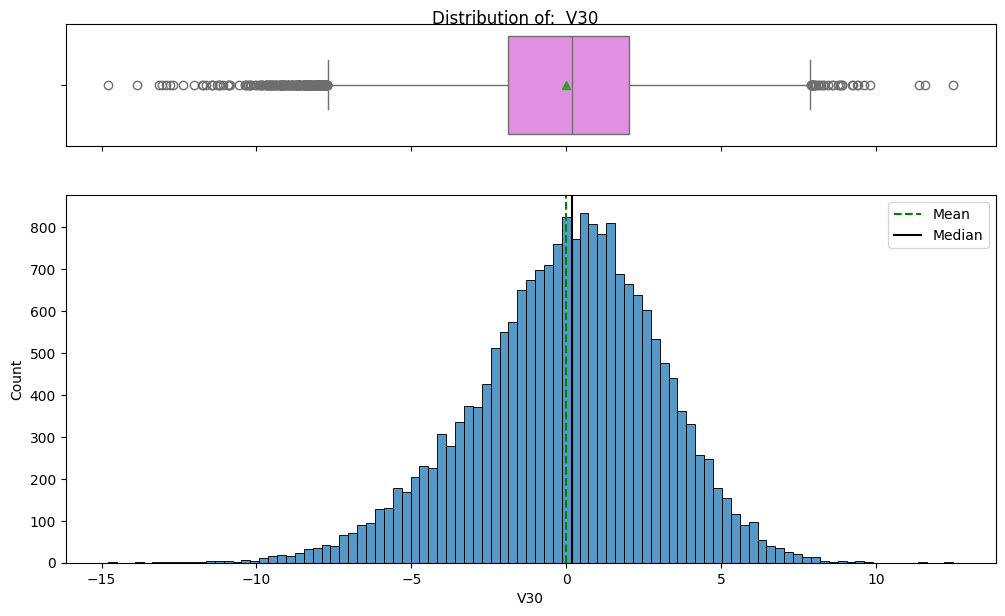

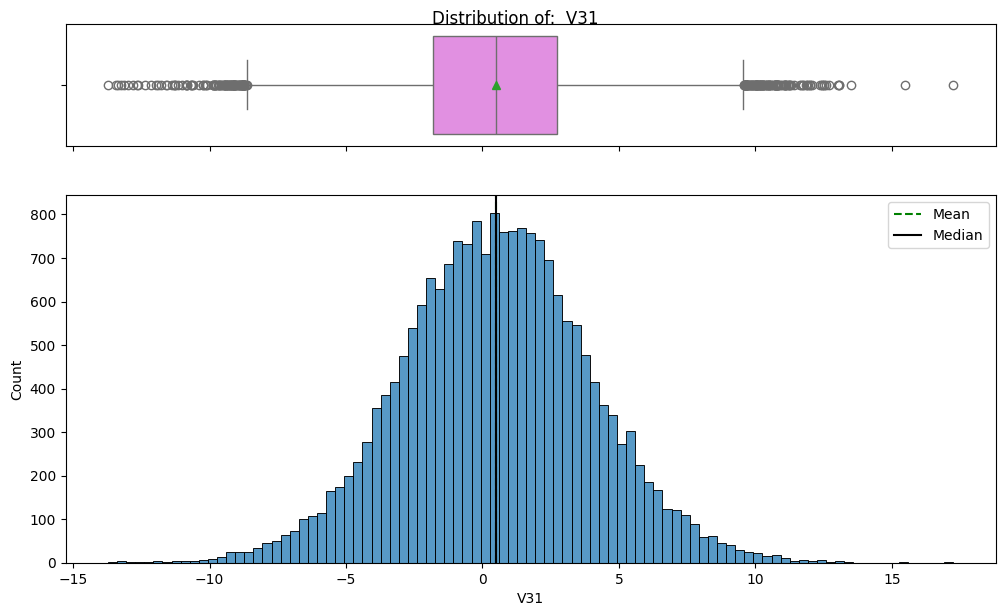

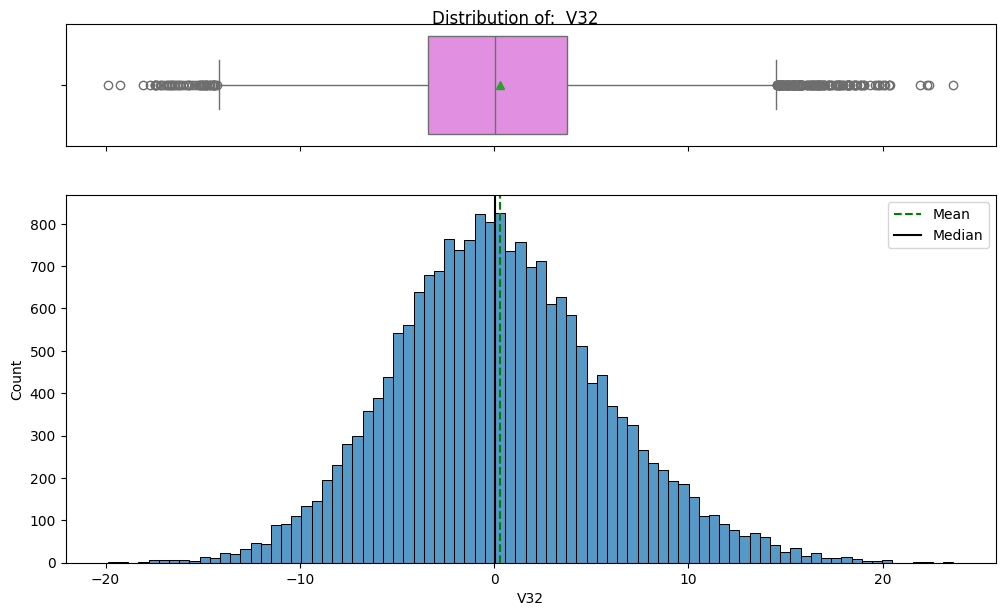

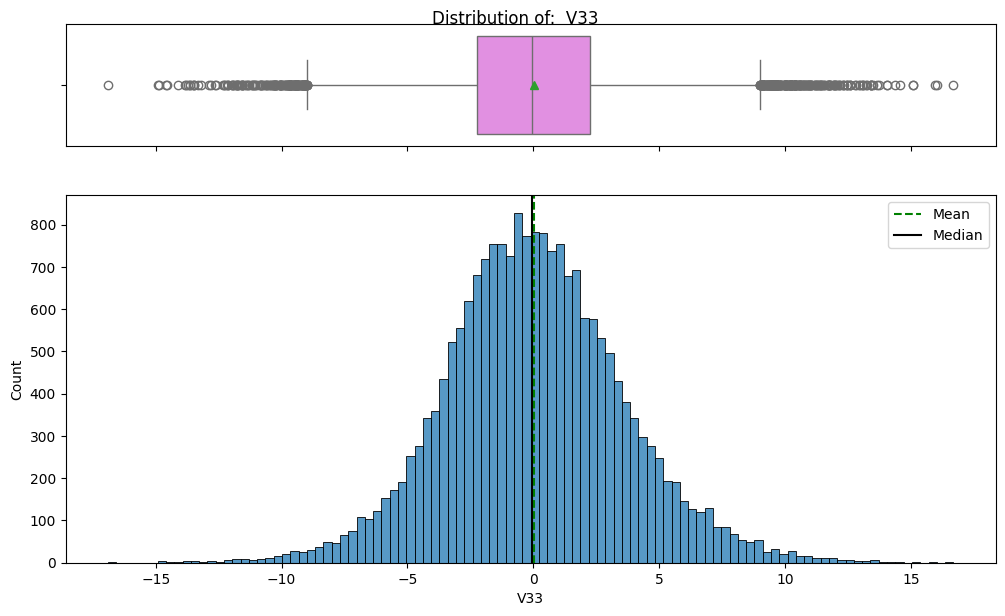

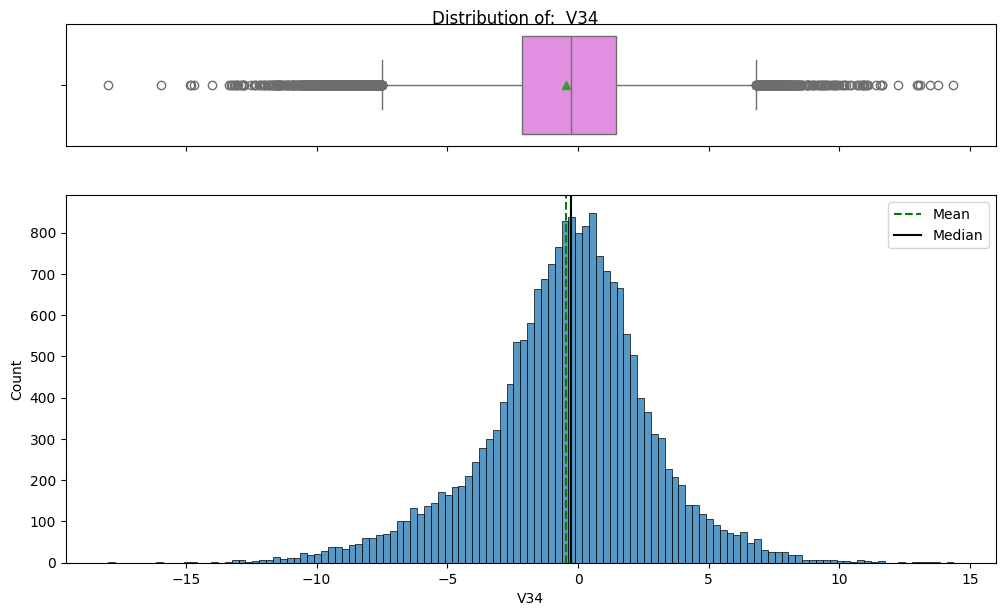

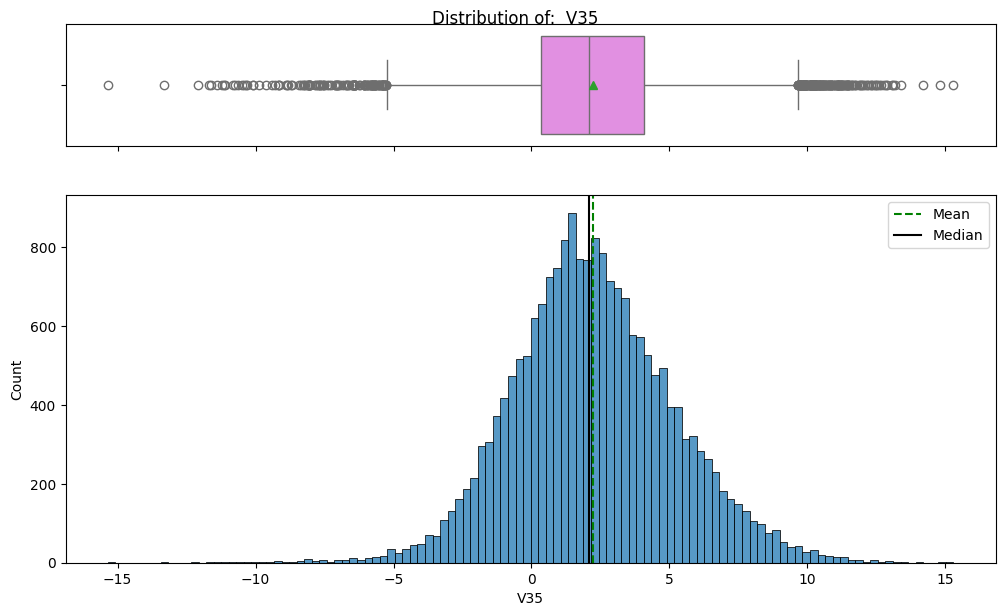

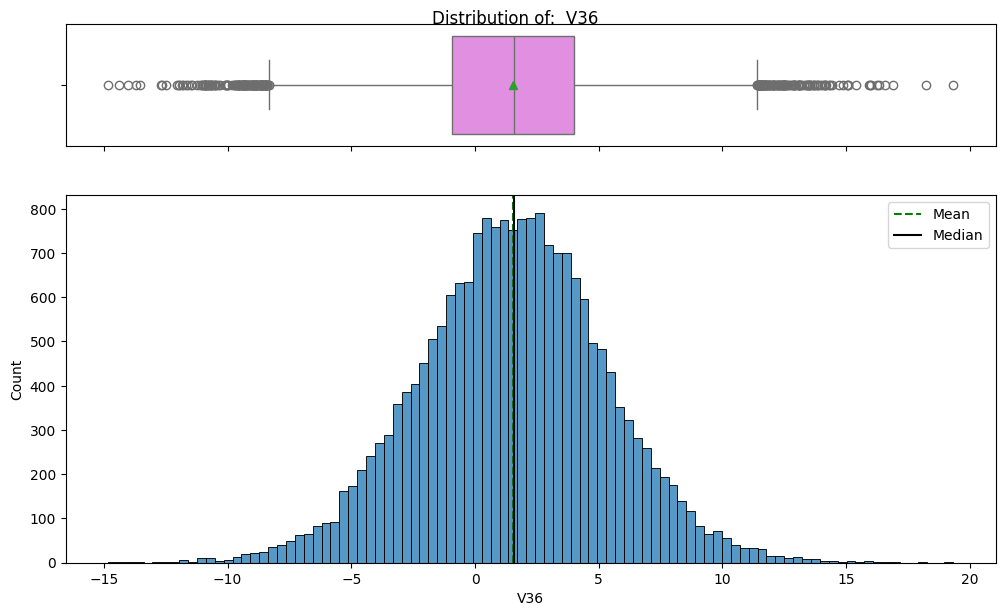

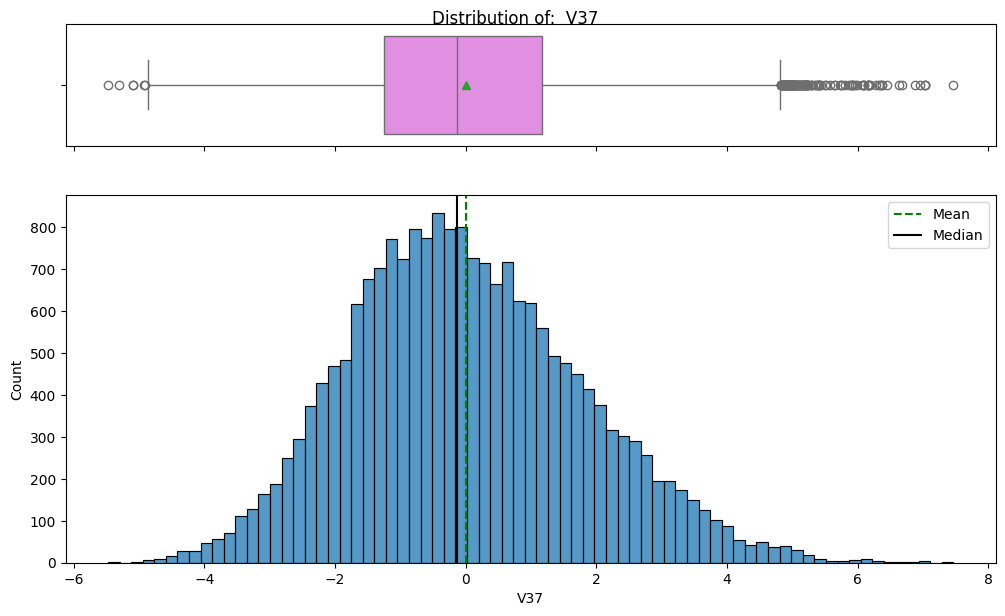

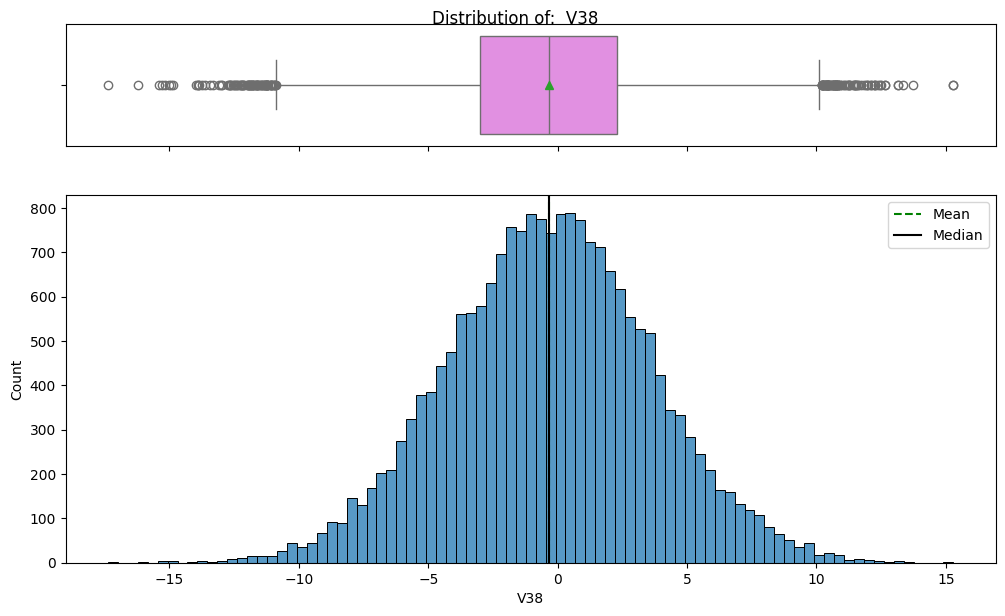

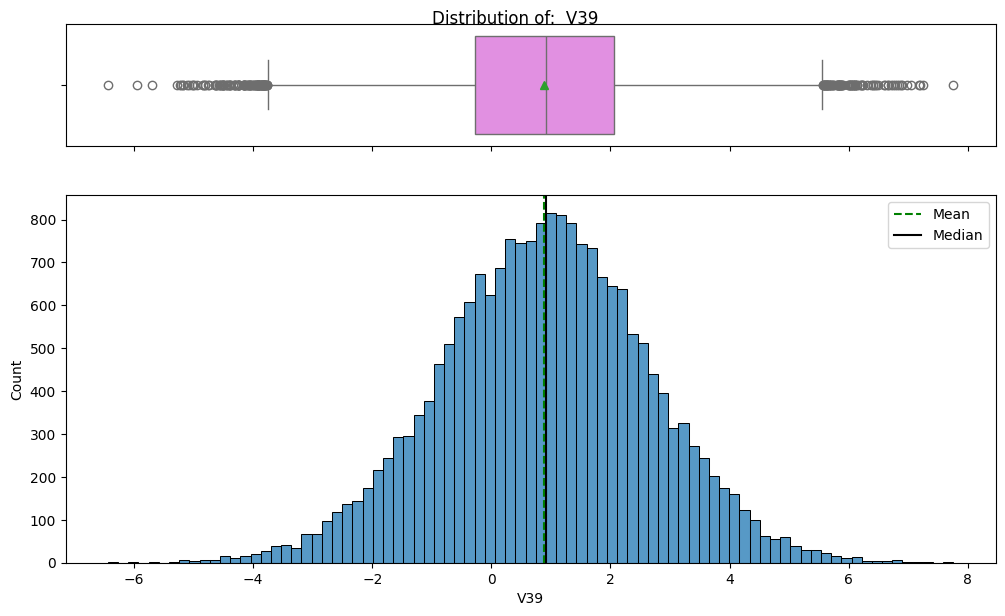

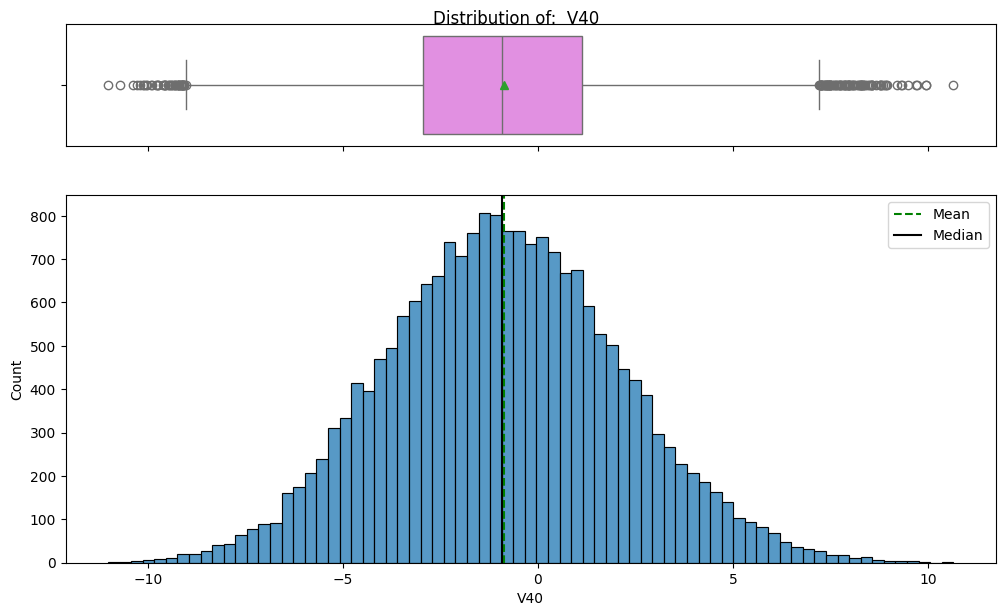

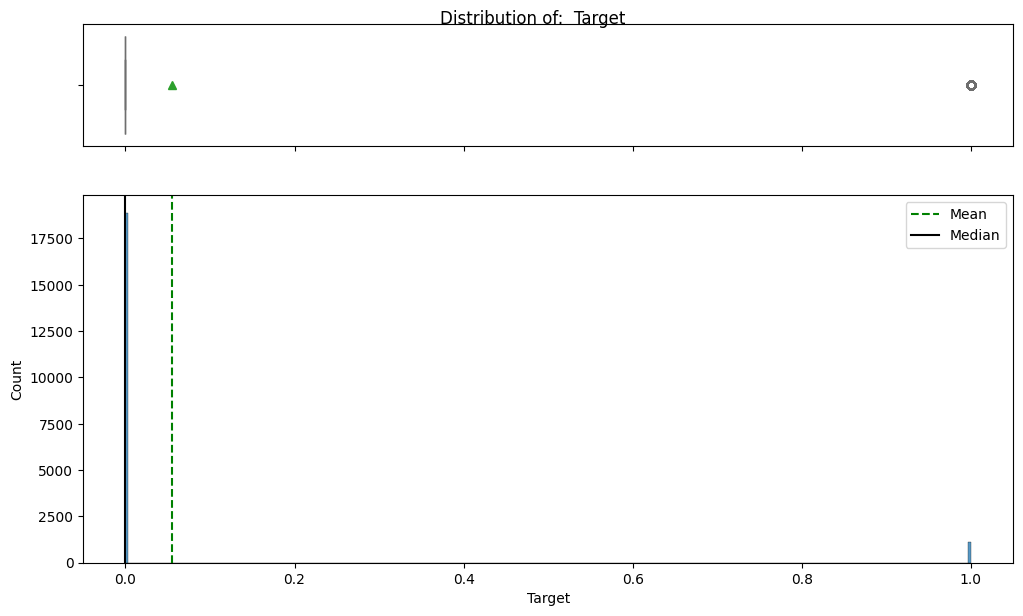

In [21]:
for feature in df.columns:
    histogram_boxplot(df, feature, figsize=(12, 7), kde=False, bins=None, title=f"Distribution of:  {feature}")

**Observations:**
* The distributions of V1 to V40 vary slightly, with some exhibiting symmetry and others showing skewness.
* There are outliers in almost all the features, and in both whiskers.

### Checking the distrubution of Target variable.

In [22]:
# For train data.
df["Target"].value_counts(1)

Target
0.0    0.9445
1.0    0.0555
Name: proportion, dtype: float64

In [23]:
# For test data.
df_test["Target"].value_counts(1)

Target
0.0    0.9436
1.0    0.0564
Name: proportion, dtype: float64

## Bivariate Analysis.

### Correlation Check.

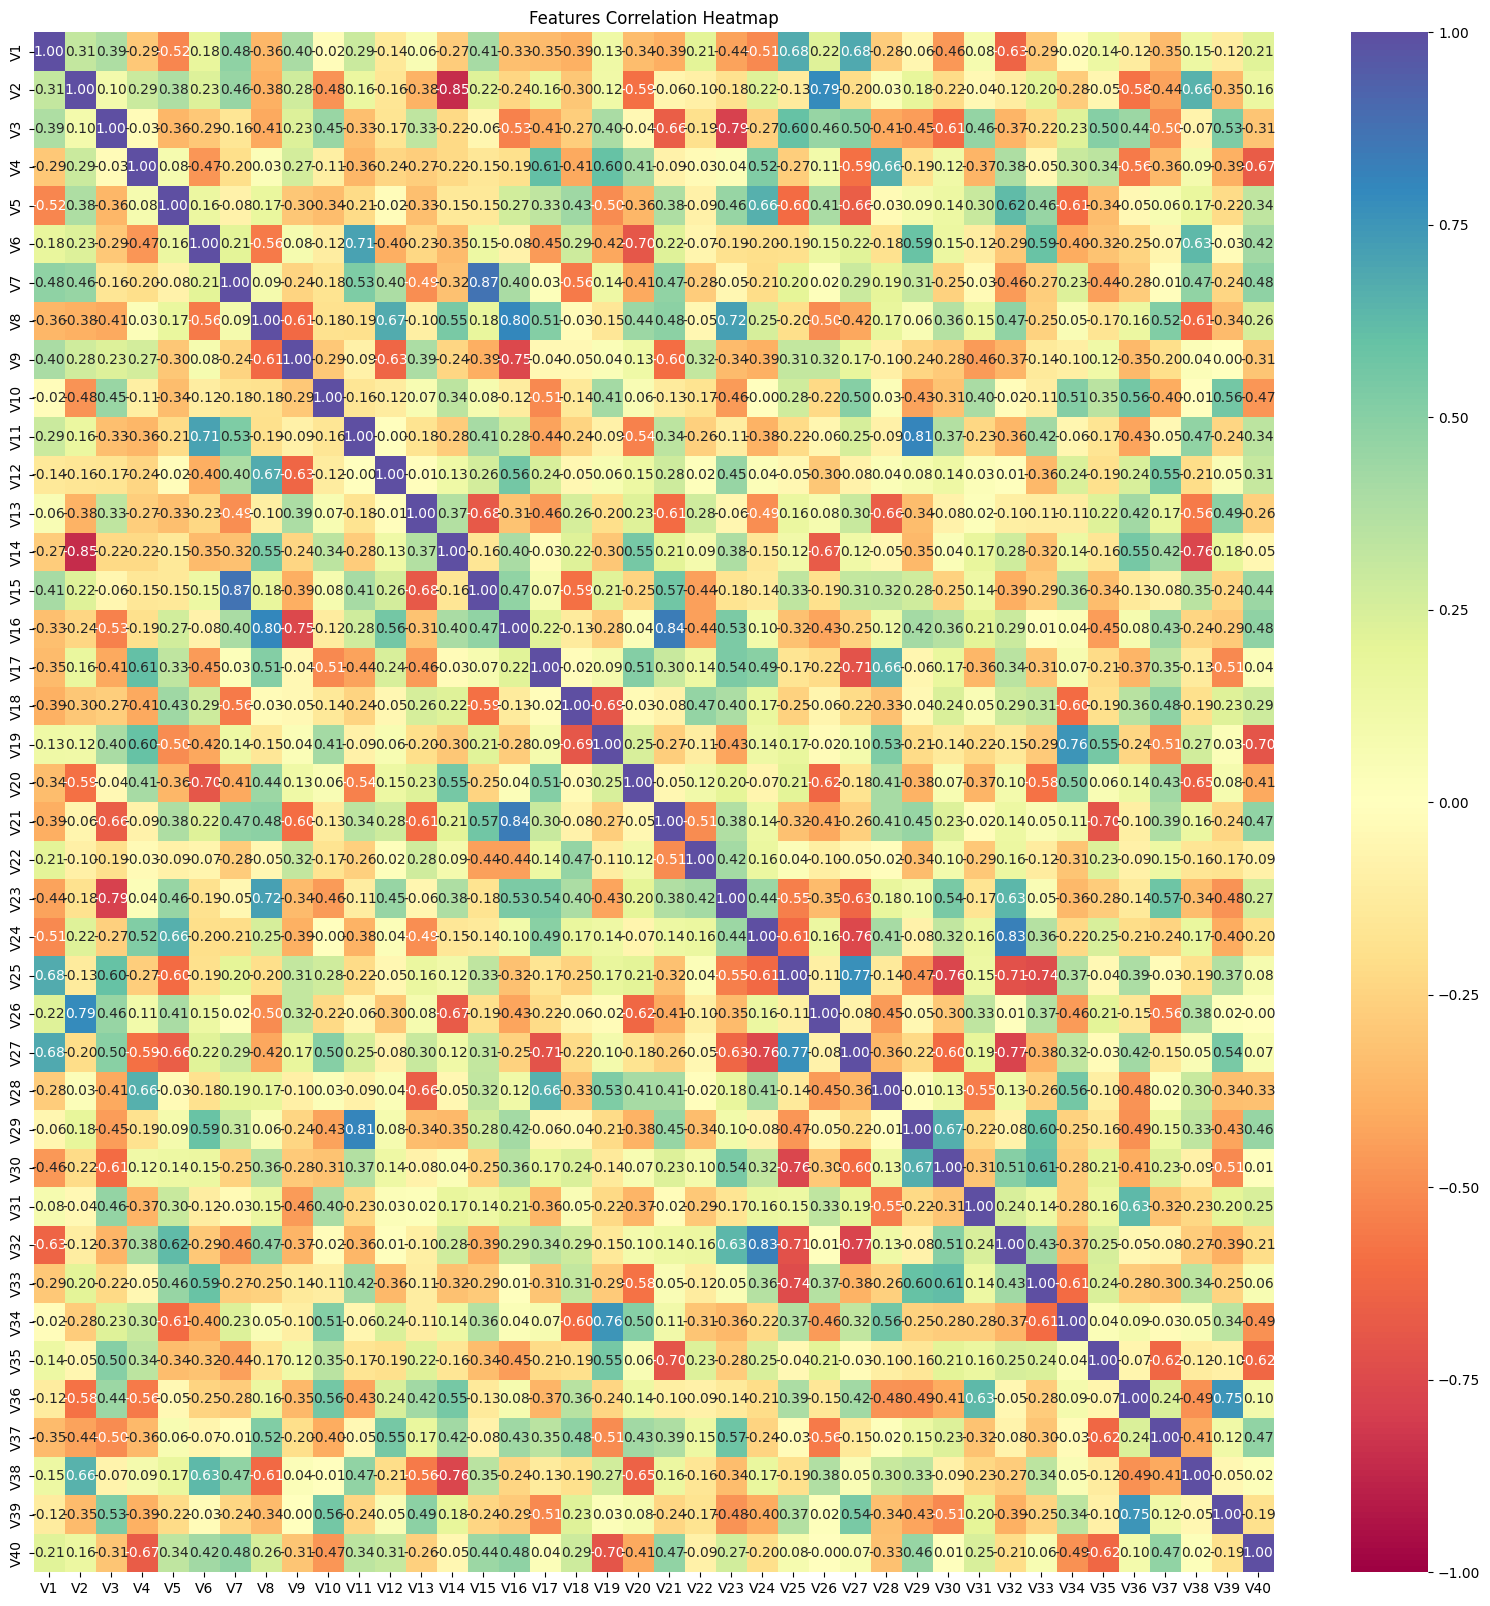

In [24]:
cols_list = df.select_dtypes(include=np.number).columns.tolist()
cols_list.remove("Target")

plt.figure(figsize=(20, 20))
sns.heatmap(
    df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.title('Features Correlation Heatmap');

**Observations:**
* There are some highly positively correlated features with each other (e.g., V15 and V7 have a correlation of 0.87) and some negatively correlated features with each other (e.g., V14 and V2 have a correlation of -0.85).

# **Data Preprocessing**

In [25]:
# Divide train data into X and y.

# Drop the 'Target' column
X = df.drop(["Target"] , axis=1)

# Column named 'Target' becomes y.
y = df["Target"]

**Since we already have a separate test set, we don't need to divide data into train, valiation and test**


In [26]:
# Split data into training and validation set with 20% of the data allocated to validation set.

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [27]:
# Checking the number of rows and columns in the X_train data.
X_train.shape

(16000, 40)

In [28]:
# Checking the number of rows and columns in the X_val data.
X_val.shape

(4000, 40)

In [29]:
# Divide test data into X_test and y_test.

# Drop the 'Target' column for X.
X_test = df_test.drop(["Target"] , axis= 1)

# Retain only 'Target' column for y
y_test = df_test["Target"]

In [30]:
# Checking the number of rows and columns in the X_test data.
X_test.shape

(5000, 40)

## Missing Value Imputation.


- There were few missing values in V1 and V2, we will impute them using the median.
- And to avoid data leakage we will impute missing values after splitting train data into train and validation sets.




In [31]:
imputer = SimpleImputer(strategy="median")

In [32]:
# Fit and transform the train data.
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

# Transform the validation data.
X_val = pd.DataFrame(imputer.transform(X_val), columns=X_train.columns)    

# Transform the test data.
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_train.columns)    

In [33]:
# Checking that no column has missing values in train or test sets
print(X_train.isna().sum())
print("-" * 30)
print(X_val.isna().sum())
print("-" * 30)
print(X_test.isna().sum())

V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22

### Normalization.

In [34]:
# Standardizing all the columns as they have different ranges.
# This is to ensure that all features contribute equally, training becomes more stable, and the network can learn faster.

# Initialize StandardScaler.
scaler = StandardScaler()

In [35]:
# Fit the scaler on the training data and transform it.

X_train = scaler.fit_transform(X_train)

# Transform the validation data using the scaler fitted on the training data.

X_val = scaler.transform(X_val)

# Transform the test data using the scaler fitted on the training data.

X_test = scaler.transform(X_test)

In [36]:
print("type(X_train) : ", type(X_train))
print("type(X_val) : ", type(X_val))
print("type(X_test) : ", type(X_test))

type(X_train) :  <class 'numpy.ndarray'>
type(X_val) :  <class 'numpy.ndarray'>
type(X_test) :  <class 'numpy.ndarray'>


In [37]:
print("X_train shape : ", X_train.shape)
print("X_val shape : ", X_val.shape)
print("X_test shape : ", X_test.shape)

X_train shape :  (16000, 40)
X_val shape :  (4000, 40)
X_test shape :  (5000, 40)


In [38]:
# Convert target variables to NumPy arrays for compatibility with neural network libraries.
y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

In [39]:
print("y_train shape : ", y_train.shape)
print("y_val shape : ", y_val.shape)
print("y_test shape : ", y_test.shape)

y_train shape :  (16000,)
y_val shape :  (4000,)
y_test shape :  (5000,)


**Observations:**
* The dataset contains only numerical features and a binary target variable, so categorical encoding is not required.
* Missing values in features V1 and V2 in train, validation and test sets were imputed with median.
* The predictor variables have a wide range of values, so normalization was used for optimal neural network performance.
* The target variable exhibits class imbalance, which will be addressed using oversampling technique (SMOTE).

# **Model Building**

## Model Evaluation Criterion

Write down the model evaluation criterion with rationale

**Model Objective:**
* Create a classification model that helps identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

**Model's possible wrong predictions (confusion matrix):**

*  Predicts "No failure" (0), but in reality the equipment fails and needs to be replaced **(FN)**.

*  Predicts "Failure" (1), but in reality the equipment is working and it can be verified by inspection **(FP)**.

**Impact of wrong predictions:**

*  For False Negatives (FN) — Replacement costs are the highest and complex (downtimes, aquisition, installation, etc.).

*  For False Positives (FP) — Inspection cost is lower than reparation costs for True Positives.

**Model Focus:**

* As False Negatives represent the highest costs, is important to convert to True Positives.

* Minimizing False Negatives is crucial. This translates to prioritizing a model that has a high **Recall** for the positive class (Failure). Recall measures the model's ability to identify all actual positive instances. A higher recall means the model is better at detecting failures, thus reducing the number of missed failures (False Negatives) and the associated high replacement costs.

**General Model:**

*  For this project a basic neural network will be created and then tuned.


## Pre-processing

### Creating a new training dataset using oversampling.

In [40]:
print("Before OverSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train == 0)))

# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy=1, k_neighbors=4, random_state=1)
X_train_o, y_train_o = sm.fit_resample(X_train, y_train)


print("After OverSampling, counts of label '1': {}".format(sum(y_train_o == 1)))
print("After OverSampling, counts of label '0': {} \n".format(sum(y_train_o == 0)))


print("After OverSampling, the shape of train_X: {}".format(X_train_o.shape))
print("After OverSampling, the shape of train_y: {} \n".format(y_train_o.shape))

Before OverSampling, counts of label '1': 888
Before OverSampling, counts of label '0': 15112 

After OverSampling, counts of label '1': 15112
After OverSampling, counts of label '0': 15112 

After OverSampling, the shape of train_X: (30224, 40)
After OverSampling, the shape of train_y: (30224,) 



**We are now done with pre-processing and evaluation criterion, so let's start building the model.**

## Utility Functions

In [41]:
def plot(history, name):
    """
    Function to plot loss/recall

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Recall
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train recall or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation recall or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

Dataframe to store the results from all the models built.

In [42]:
# Create a blank DataFrame to store the training and validation evaluation results of different models.

evaluation_results = pd.DataFrame(columns=['Model', '# hidden layers', '# neurons hidden layer', 'activation function hidden layer', 'optimizer', '# epochs', 'batch size', 'Train_Loss', 'Train_Recall',
                                         'Val_Loss', 'Val_Recall', 'Time (in s)'])


In [43]:
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,optimizer,# epochs,batch size,Train_Loss,Train_Recall,Val_Loss,Val_Recall,Time (in s)


In [44]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors) > threshold
    # pred_temp = model.predict(predictors) > threshold
    # # rounding off the above values to get classes
    # pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='macro')  # to compute Recall
    precision = precision_score(target, pred, average='macro')  # to compute Precision
    f1 = f1_score(target, pred, average='macro')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,}, index = [0]
    )

    return df_perf

## Base Model and Initial Model (Model 0) Building.

- For Base Model a neural network of just input and output layer with Sigmoid activation.

- For Initial model, let's start with a neural network consisting of:
  - just one hidden layer
  - activation function of ReLU
  - SGD as the optimizer

In [45]:
# Defining initial batch size and # epochs.
epochs = 100    
batch_size = X_train.shape[0] # using the whole set.

In [179]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [47]:
#Initializing the neural network
modelb = Sequential()

# Adding a dense layer with sigmoid activation function, with the input dimension determined by the shape of the training data.
modelb.add(Dense(1, activation='sigmoid', input_shape=(X_train.shape[1],)))

In [48]:
#Printing the summary
modelb.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [49]:
# Defining SGD as the optimizer to be used.

optimizer = tf.keras.optimizers.SGD()   

modelb.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) 


In [50]:
start = time.time()

history = modelb.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)

end = time.time()

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - Recall: 0.3615 - loss: 0.9652 - val_Recall: 0.3333 - val_loss: 0.9663
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - Recall: 0.3592 - loss: 0.9579 - val_Recall: 0.3378 - val_loss: 0.9589
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - Recall: 0.3615 - loss: 0.9507 - val_Recall: 0.3468 - val_loss: 0.9516
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - Recall: 0.3626 - loss: 0.9436 - val_Recall: 0.3468 - val_loss: 0.9444
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - Recall: 0.3660 - loss: 0.9366 - val_Recall: 0.3468 - val_loss: 0.9372
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - Recall: 0.3660 - loss: 0.9297 - val_Recall: 0.3423 - val_loss: 0.9301
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - Recall: 0.3649 - loss: 0.9228 - val_Recall: 0.3423 - val_loss: 0.9232
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - Recall: 0.3671 - loss: 0.9160 - val_Recall: 0.3423 - val_loss: 0.9163
Epoch 9/100
1/1 ━━━━━━━

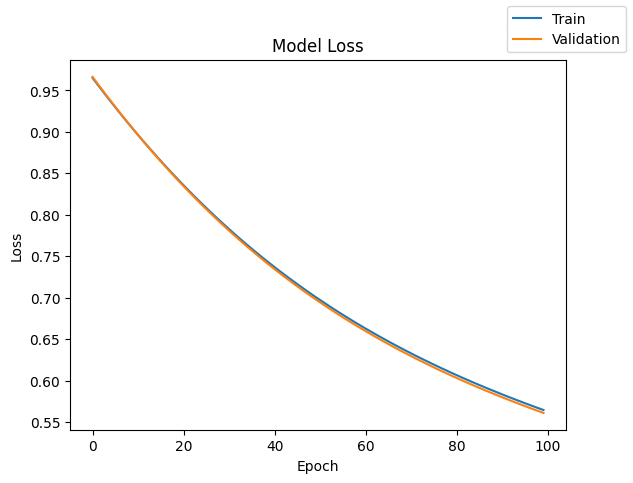

In [51]:
plot(history,'loss')

In [52]:
evaluation_results.loc[0] = ['Base Model', '-', '-', '-', 'SGD', epochs, batch_size, history.history["loss"][-1], history.history["Recall"][-1], history.history["val_loss"][-1], history.history["val_Recall"][-1], round(end-start,2)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,optimizer,# epochs,batch size,Train_Loss,Train_Recall,Val_Loss,Val_Recall,Time (in s)
0,Base Model,-,-,-,SGD,100,16000,0.564904,0.458333,0.561399,0.463964,5.2


### Model 0

In [53]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [54]:
#Initializing the neural network.
model_0 = Sequential()
model_0.add(Dense( 64 ,activation="relu",input_dim=X_train.shape[1])) #using input_dim instead of input_shape as shortcut for 1D input.
model_0.add(Dense( 1 ,activation="sigmoid"))

In [55]:
model_0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# Defining SGD as the optimizer to be used.

optimizer = tf.keras.optimizers.SGD()   

model_0.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) 


In [57]:
start = time.time()

history0 = model_0.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)

end = time.time()

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - Recall: 0.9707 - loss: 1.0961 - val_Recall: 0.9730 - val_loss: 1.0591
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - Recall: 0.9640 - loss: 1.0561 - val_Recall: 0.9640 - val_loss: 1.0206
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - Recall: 0.9471 - loss: 1.0182 - val_Recall: 0.9550 - val_loss: 0.9842
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - Recall: 0.9257 - loss: 0.9822 - val_Recall: 0.9144 - val_loss: 0.9497
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - Recall: 0.9133 - loss: 0.9482 - val_Recall: 0.9009 - val_loss: 0.9171
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - Recall: 0.8998 - loss: 0.9160 - val_Recall: 0.8964 - val_loss: 0.8862
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - Recall: 0.8660 - loss: 0.8855 - val_Recall: 0.8694 - val_loss: 0.8570
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - Recall: 0.8266 - loss: 0.8566 - val_Recall: 0.8514 - val_loss: 0.8294
Epoch 9/100
1/1 ━━━━━━━

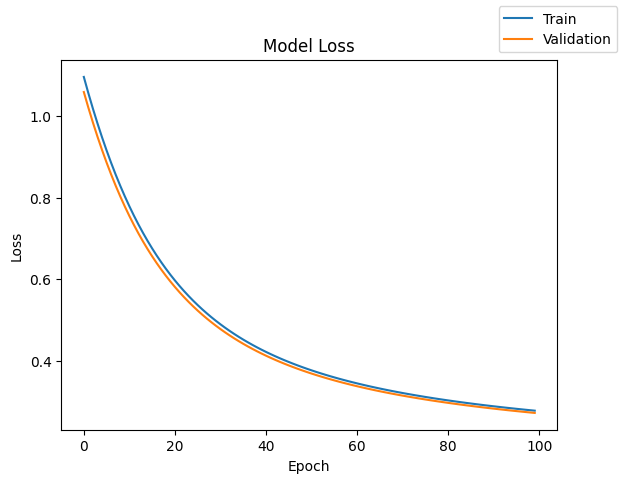

In [58]:
plot(history0,'loss')

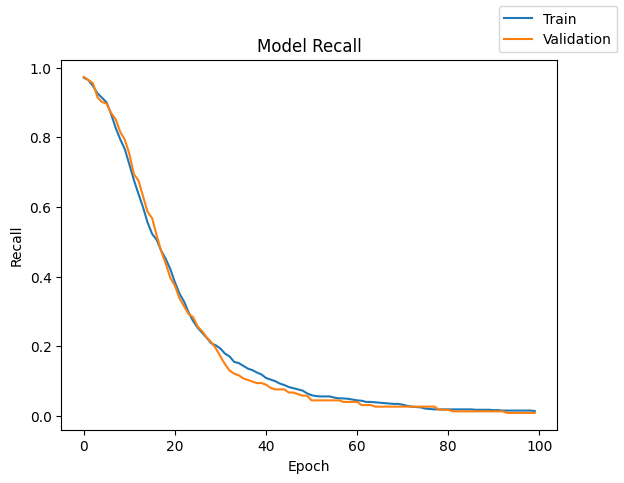

In [59]:
plot(history0,'Recall')

In [60]:
evaluation_results.loc[0] = ['Model 0', '1', '64', 'relu', 'SGD', epochs, batch_size, history0.history["loss"][-1], history0.history["Recall"][-1], history0.history["val_loss"][-1], history0.history["val_Recall"][-1], round(end-start,2)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,optimizer,# epochs,batch size,Train_Loss,Train_Recall,Val_Loss,Val_Recall,Time (in s)
0,Model 0,1,64,relu,SGD,100,16000,0.278554,0.01464,0.273013,0.009009,5.42


In [61]:
model_0_train_perf = model_performance_classification(model_0, X_train, y_train)
model_0_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 257us/step


,Accuracy,Recall,Precision,F1 Score
0,0.944688,0.506989,0.755226,0.500037


In [62]:
model_0_val_perf = model_performance_classification(model_0,X_val,y_val)
model_0_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 298us/step


,Accuracy,Recall,Precision,F1 Score
0,0.94475,0.504372,0.805813,0.494677


Let's check the classification reports.

In [63]:
y_train_pred_0 = model_0.predict(X_train)
y_val_pred_0 = model_0.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 228us/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 278us/step


In [64]:
print("Classification Report - Train data Model_0",end="\n\n")
cr_train_model_0 = classification_report(y_train,y_train_pred_0>0.5)
print(cr_train_model_0)

Classification Report - Train data Model_0

              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97     15112
         1.0       0.57      0.01      0.03       888

    accuracy                           0.94     16000
   macro avg       0.76      0.51      0.50     16000
weighted avg       0.92      0.94      0.92     16000



In [65]:
print("Classification Report - Validation data Model_0",end="\n\n")
cr_val_model_0 = classification_report(y_val,y_val_pred_0>0.5)
print(cr_val_model_0)

Classification Report - Validation data Model_0

              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97      3778
         1.0       0.67      0.01      0.02       222

    accuracy                           0.94      4000
   macro avg       0.81      0.50      0.49      4000
weighted avg       0.93      0.94      0.92      4000



**Observations:**
* Base Model and Model 0
    * In the Base Model (BM) loss function decreses almost linearly, while in Model 0 shows a curve that begins to slightly flatten around 50 epochs.
    * Recall for BM and Model 0 is around 50% for both sets.
    * Model 0 is showing poor identification of class 1 (around 1%).

# **Model Performance Improvement**

## Model 1

- Let's try adding another layer to see if we can improve our model's performance.

In [66]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [67]:
#Initializing the neural network.
model_1 = Sequential()
model_1.add(Dense( 64 ,activation="relu",input_dim=X_train.shape[1]))
model_1.add(Dense( 32,activation="relu")) 
model_1.add(Dense( 1 ,activation="sigmoid"))

In [68]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [69]:
# Defining SGD as the optimizer to be used.

optimizer = tf.keras.optimizers.SGD()   

model_1.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) 


In [70]:
start = time.time()

history1 = model_1.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)

end = time.time()

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - Recall: 0.0619 - loss: 0.5172 - val_Recall: 0.0766 - val_loss: 0.5136
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - Recall: 0.0518 - loss: 0.5055 - val_Recall: 0.0676 - val_loss: 0.5023
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - Recall: 0.0417 - loss: 0.4944 - val_Recall: 0.0586 - val_loss: 0.4915
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - Recall: 0.0372 - loss: 0.4840 - val_Recall: 0.0450 - val_loss: 0.4813
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - Recall: 0.0327 - loss: 0.4741 - val_Recall: 0.0360 - val_loss: 0.4717
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - Recall: 0.0315 - loss: 0.4647 - val_Recall: 0.0315 - val_loss: 0.4625
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - Recall: 0.0304 - loss: 0.4558 - val_Recall: 0.0315 - val_loss: 0.4538
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - Recall: 0.0270 - loss: 0.4473 - val_Recall: 0.0225 - val_loss: 0.4456
Epoch 9/100
1/1 ━━━━━━━

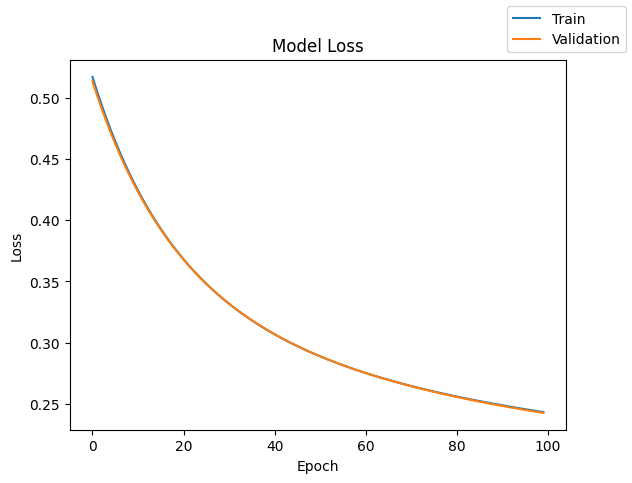

In [71]:
plot(history1,'loss')

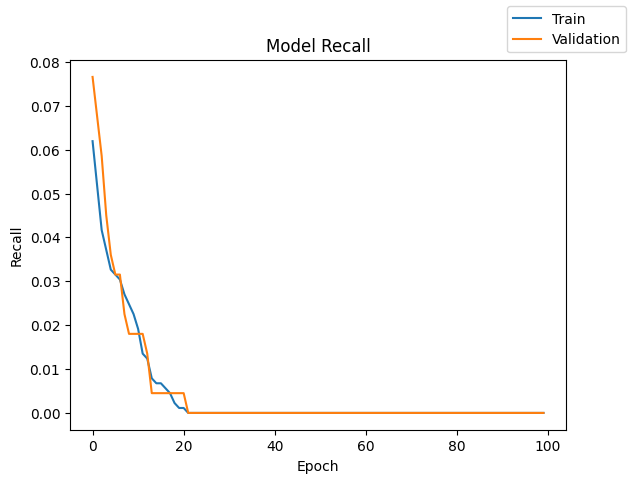

In [72]:
plot(history1,'Recall')

In [73]:
evaluation_results.loc[1] = ['Model 1', '2', '64, 32', 'relu, relu', 'SGD', epochs, batch_size, history1.history["loss"][-1], history1.history["Recall"][-1], history1.history["val_loss"][-1], history1.history["val_Recall"][-1], round(end-start,2)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,optimizer,# epochs,batch size,Train_Loss,Train_Recall,Val_Loss,Val_Recall,Time (in s)
0,Model 0,1,64,relu,SGD,100,16000,0.278554,0.01464,0.273013,0.009009,5.42
1,Model 1,2,"64, 32","relu, relu",SGD,100,16000,0.243223,0.00000,0.242557,0.000000,5.54


In [74]:
model_1_train_perf = model_performance_classification(model_1, X_train, y_train)
model_1_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 250us/step


,Accuracy,Recall,Precision,F1 Score
0,0.9445,0.5,0.47225,0.485729


In [75]:
model_1_val_perf = model_performance_classification(model_1,X_val,y_val)
model_1_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 359us/step


,Accuracy,Recall,Precision,F1 Score
0,0.9445,0.5,0.47225,0.485729


Let's check the classification reports.

In [76]:
y_train_pred_1 = model_1.predict(X_train)
y_val_pred_1 = model_1.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 241us/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 284us/step


In [77]:
print("Classification Report - Train data Model_1",end="\n\n")
cr_train_model_1 = classification_report(y_train,y_train_pred_1>0.5)
print(cr_train_model_1)

Classification Report - Train data Model_1

              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97     15112
         1.0       0.00      0.00      0.00       888

    accuracy                           0.94     16000
   macro avg       0.47      0.50      0.49     16000
weighted avg       0.89      0.94      0.92     16000



In [78]:
print("Classification Report - Validation data Model_1",end="\n\n")
cr_val_model_1 = classification_report(y_val,y_val_pred_1>0.5)
print(cr_val_model_1)

Classification Report - Validation data Model_1

              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97      3778
         1.0       0.00      0.00      0.00       222

    accuracy                           0.94      4000
   macro avg       0.47      0.50      0.49      4000
weighted avg       0.89      0.94      0.92      4000



**Observations:**
* Model 1
    * Model 1 loss function shows almost the same behavior as Model 0.
    * There is no significant improvement from Model 0.

## Model 2

Changing the batch size to 32 (16000/32 = 500) and adding another layer with activation tanh.

In [79]:
# Defining new batch size.
    
batch_size = 32

In [80]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [81]:
#Initializing the neural network.
model_2 = Sequential()
model_2.add(Dense( 64 ,activation="relu",input_dim=X_train.shape[1]))
model_2.add(Dense( 32,activation="relu")) 
model_2.add(Dense( 4,activation="tanh"))
model_2.add(Dense( 1 ,activation="sigmoid"))

In [82]:
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,841 (18.91 KB)

 Trainable params: 4,841 (18.91 KB)

 Non-trainable params: 0 (0.00 B)

In [83]:
# Defining SGD as the optimizer to be used.

optimizer = tf.keras.optimizers.SGD()   

model_2.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) 


In [84]:
start = time.time()

history2 = model_2.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)

end = time.time()

Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 677us/step - Recall: 0.0214 - loss: 0.2615 - val_Recall: 0.0000e+00 - val_loss: 0.1850
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 536us/step - Recall: 0.0000e+00 - loss: 0.1707 - val_Recall: 0.0090 - val_loss: 0.1515
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 553us/step - Recall: 0.1565 - loss: 0.1362 - val_Recall: 0.3378 - val_loss: 0.1200
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 608us/step - Recall: 0.4268 - loss: 0.1091 - val_Recall: 0.5360 - val_loss: 0.1007
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 539us/step - Recall: 0.5473 - loss: 0.0923 - val_Recall: 0.6577 - val_loss: 0.0880
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 538us/step - Recall: 0.6464 - loss: 0.0803 - val_Recall: 0.7387 - val_loss: 0.0787
Epoch 7/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 542us/step - Recall: 0.7230 - loss: 0.0716 - val_Recall: 0.7838 - val_loss: 0.0719
Epoch 8/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step - Recall: 0.7635 - loss: 0.0654 - val_Recall: 0.

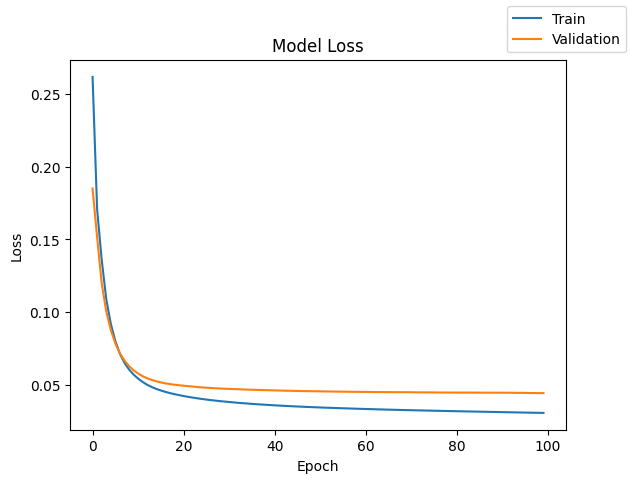

In [85]:
plot(history2,'loss')

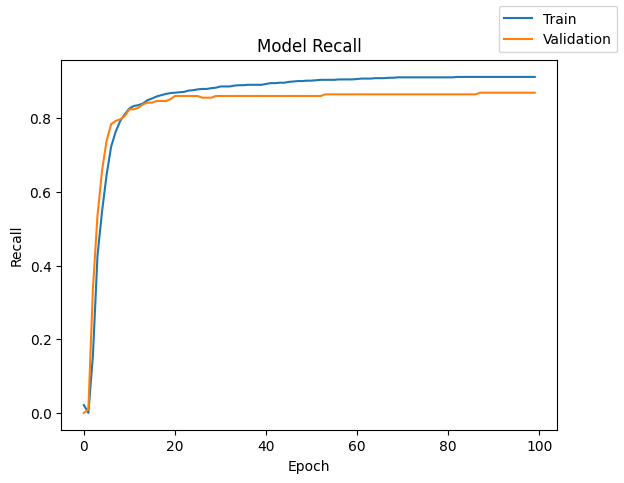

In [86]:
plot(history2,'Recall')

In [87]:
evaluation_results.loc[2] = ['Model 2', '3', '64, 32, 4', 'relu, relu, tanh', 'SGD', epochs, batch_size, history2.history["loss"][-1], history2.history["Recall"][-1], history2.history["val_loss"][-1], history2.history["val_Recall"][-1], round(end-start,2)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,optimizer,# epochs,batch size,Train_Loss,Train_Recall,Val_Loss,Val_Recall,Time (in s)
0,Model 0,1,64,relu,SGD,100,16000,0.278554,0.014640,0.273013,0.009009,5.42
1,Model 1,2,"64, 32","relu, relu",SGD,100,16000,0.243223,0.000000,0.242557,0.000000,5.54
2,Model 2,3,"64, 32, 4","relu, relu, tanh",SGD,100,32,0.031047,0.912162,0.044640,0.869369,28.86


In [88]:
model_2_train_perf = model_performance_classification(model_2, X_train, y_train)
model_2_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 254us/step


,Accuracy,Recall,Precision,F1 Score
0,0.995,0.957075,0.995046,0.975206


In [89]:
model_2_val_perf = model_performance_classification(model_2,X_val,y_val)
model_2_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 365us/step


,Accuracy,Recall,Precision,F1 Score
0,0.991,0.933758,0.978684,0.954971


Let's check the classification reports.

In [90]:
y_train_pred_2 = model_2.predict(X_train)
y_val_pred_2 = model_2.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 251us/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 296us/step


In [91]:
print("Classification Report - Train data Model_2",end="\n\n")
cr_train_model_2 = classification_report(y_train,y_train_pred_2>0.5)
print(cr_train_model_2)

Classification Report - Train data Model_2

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     15112
         1.0       1.00      0.91      0.95       888

    accuracy                           0.99     16000
   macro avg       1.00      0.96      0.98     16000
weighted avg       1.00      0.99      0.99     16000



In [92]:
print("Classification Report - Validation data Model_2",end="\n\n")
cr_val_model_2 = classification_report(y_val,y_val_pred_2>0.5)
print(cr_val_model_2)

Classification Report - Validation data Model_2

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      3778
         1.0       0.96      0.87      0.91       222

    accuracy                           0.99      4000
   macro avg       0.98      0.93      0.95      4000
weighted avg       0.99      0.99      0.99      4000



**Observations:**
* Model 2
    * There is a significant improvement in Recall score, with the model identifying around 87% of class 1 in the validation set.
    * Loss and Recall began to plateau and diverge after few epochs (less than 20), suggesting values of 50 could be used instead of 100.
    * Training time increased 6 times as expected by using small batch size.

## Model 3

As dataset presents class imbalance, model 3 will use:

- **Class Weights:** We compute class weights to adjust the loss function, penalizing the model more heavily for misclassifying the minority class to ensure it learns distinct features for both.

In [93]:
# Calculate class weights for imbalanced dataset. This gives higher weight to the minority class.
cw = (y_train.shape[0]) / np.bincount(y_train.astype(int)) # The total number of samples is divided by the count of each class. The resulting array cw has one value per class.

# # Creates the dictionary cw_dict where the key is the class index (0 or 1) and the value is the calculated weight.
cw_dict = {}
for i in range(cw.shape[0]):
    cw_dict[i] = cw[i]

cw_dict

{0: np.float64(1.0587612493382743), 1: np.float64(18.01801801801802)}

In [94]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [95]:
#Initializing the neural network.
model_3 = Sequential()
model_3.add(Dense( 64 ,activation="relu",input_dim=X_train.shape[1]))
model_3.add(Dense( 32,activation="relu"))
model_3.add(Dense( 4,activation="tanh")) 
model_3.add(Dense( 1 ,activation="sigmoid"))

In [96]:
model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,841 (18.91 KB)

 Trainable params: 4,841 (18.91 KB)

 Non-trainable params: 0 (0.00 B)

In [97]:
# Defining SGD as the optimizer to be used.

optimizer = tf.keras.optimizers.SGD()   

model_3.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) 


In [98]:
start = time.time()

history3 = model_3.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs, class_weight=cw_dict)

end = time.time()

Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 691us/step - Recall: 0.8761 - loss: 0.6876 - val_Recall: 0.8829 - val_loss: 0.2361
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step - Recall: 0.8930 - loss: 0.4746 - val_Recall: 0.8964 - val_loss: 0.1811
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 543us/step - Recall: 0.9009 - loss: 0.4104 - val_Recall: 0.8964 - val_loss: 0.1597
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 537us/step - Recall: 0.9032 - loss: 0.3758 - val_Recall: 0.8964 - val_loss: 0.1528
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 570us/step - Recall: 0.9054 - loss: 0.3552 - val_Recall: 0.9054 - val_loss: 0.1541
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 553us/step - Recall: 0.9099 - loss: 0.3378 - val_Recall: 0.9054 - val_loss: 0.1447
Epoch 7/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 542us/step - Recall: 0.9155 - loss: 0.3238 - val_Recall: 0.9054 - val_loss: 0.1330
Epoch 8/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 563us/step - Recall: 0.9155 - loss: 0.3124 - val_Recall: 0.9054 - v

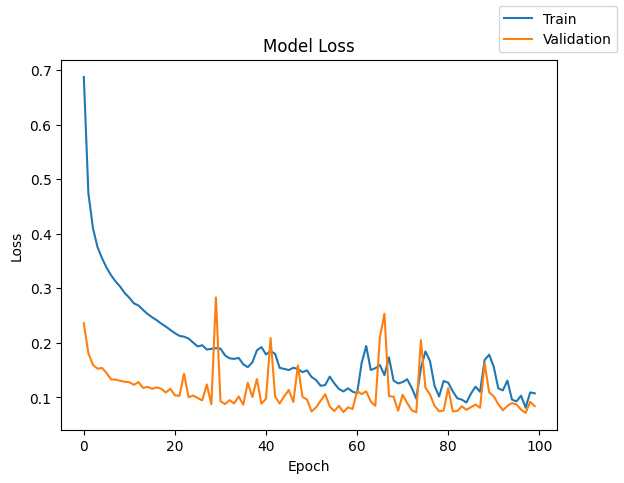

In [99]:
plot(history3,'loss')

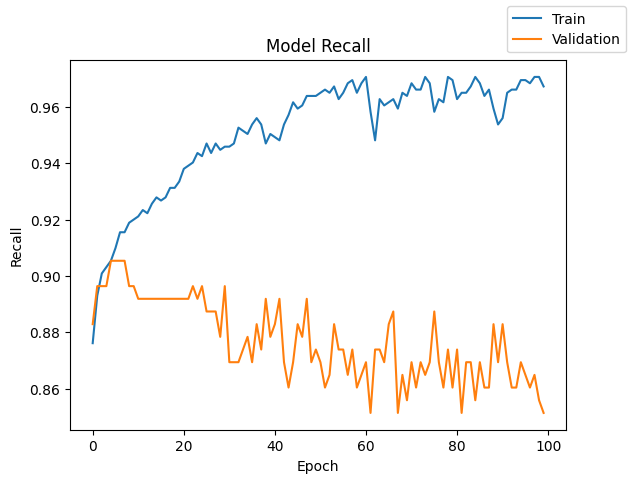

In [100]:
plot(history3,'Recall')

In [101]:
evaluation_results.loc[3] = ['Model 3 (w)', '3', '64, 32, 4', 'relu, relu, tanh', 'SGD', epochs, batch_size, history3.history["loss"][-1], history3.history["Recall"][-1], history3.history["val_loss"][-1], history3.history["val_Recall"][-1], round(end-start,2)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,optimizer,# epochs,batch size,Train_Loss,Train_Recall,Val_Loss,Val_Recall,Time (in s)
0,Model 0,1,64,relu,SGD,100,16000,0.278554,0.014640,0.273013,0.009009,5.42
1,Model 1,2,"64, 32","relu, relu",SGD,100,16000,0.243223,0.000000,0.242557,0.000000,5.54
2,Model 2,3,"64, 32, 4","relu, relu, tanh",SGD,100,32,0.031047,0.912162,0.044640,0.869369,28.86
3,Model 3 (w),3,"64, 32, 4","relu, relu, tanh",SGD,100,32,0.107541,0.967342,0.084034,0.851351,29.42


In [102]:
model_3_train_perf = model_performance_classification(model_3, X_train, y_train)
model_3_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 280us/step


,Accuracy,Recall,Precision,F1 Score
0,0.994687,0.974929,0.974426,0.974677


In [103]:
model_3_val_perf = model_performance_classification(model_3,X_val,y_val)
model_3_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 316us/step


,Accuracy,Recall,Precision,F1 Score
0,0.98475,0.92197,0.931122,0.92649


Let's check the classification reports.

In [104]:
y_train_pred_3 = model_3.predict(X_train)
y_val_pred_3 = model_3.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 252us/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 303us/step


In [105]:
print("Classification Report - Train data Model_3",end="\n\n")
cr_train_model_3 = classification_report(y_train,y_train_pred_3>0.5)
print(cr_train_model_3)

Classification Report - Train data Model_3

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     15112
         1.0       0.95      0.95      0.95       888

    accuracy                           0.99     16000
   macro avg       0.97      0.97      0.97     16000
weighted avg       0.99      0.99      0.99     16000



In [106]:
print("Classification Report - Validation data Model_3",end="\n\n")
cr_val_model_3 = classification_report(y_val,y_val_pred_3>0.5)
print(cr_val_model_3)

Classification Report - Validation data Model_3

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      3778
         1.0       0.87      0.85      0.86       222

    accuracy                           0.98      4000
   macro avg       0.93      0.92      0.93      4000
weighted avg       0.98      0.98      0.98      4000



**Observations:**
* Model 3
    * Both loss functions shows jagged plateaus due to increased error "punishment" for the 1 class.
    * Both loss functions increased from Model 2, training recall increased significantly, while verification recall stayed almost the same.

## Model 4

Using oversampled data instead of class weights to address imbalance and enhance data.

In [107]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [108]:
#Initializing the neural network.
model_4 = Sequential()
model_4.add(Dense( 64 ,activation="relu",input_dim=X_train.shape[1]))
model_4.add(Dense( 32,activation="relu"))
model_4.add(Dense( 4,activation="tanh")) 
model_4.add(Dense( 1 ,activation="sigmoid"))

In [109]:
model_4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,841 (18.91 KB)

 Trainable params: 4,841 (18.91 KB)

 Non-trainable params: 0 (0.00 B)

In [110]:
# Defining SGD as the optimizer to be used.

optimizer = tf.keras.optimizers.SGD()   

model_4.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) 


In [111]:
start = time.time()

history4 = model_4.fit(X_train_o, y_train_o, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)

end = time.time()

Epoch 1/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 593us/step - Recall: 0.8951 - loss: 0.3415 - val_Recall: 0.8649 - val_loss: 0.1942
Epoch 2/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 525us/step - Recall: 0.9085 - loss: 0.2150 - val_Recall: 0.8784 - val_loss: 0.1396
Epoch 3/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 531us/step - Recall: 0.9184 - loss: 0.1805 - val_Recall: 0.8784 - val_loss: 0.1228
Epoch 4/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 518us/step - Recall: 0.9215 - loss: 0.1619 - val_Recall: 0.8784 - val_loss: 0.1134
Epoch 5/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 524us/step - Recall: 0.9240 - loss: 0.1495 - val_Recall: 0.8784 - val_loss: 0.1085
Epoch 6/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 526us/step - Recall: 0.9256 - loss: 0.1396 - val_Recall: 0.8829 - val_loss: 0.1052
Epoch 7/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 538us/step - Recall: 0.9270 - loss: 0.1309 - val_Recall: 0.8874 - val_loss: 0.1037
Epoch 8/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 531us/step - Recall: 0.9287 - loss: 0.1228 - val_Recall: 0.8919 - v

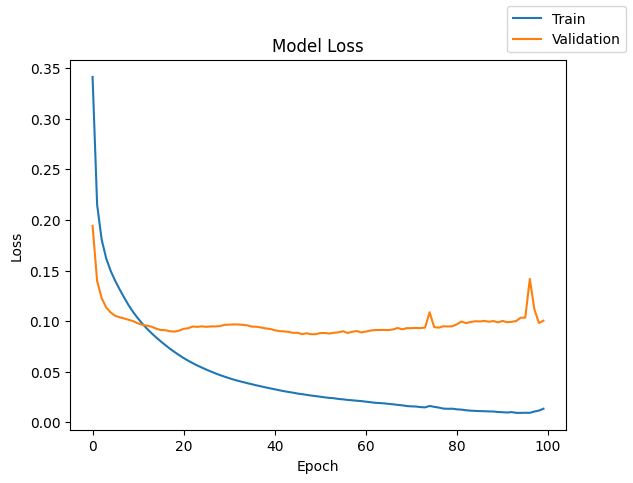

In [112]:
plot(history4,'loss')

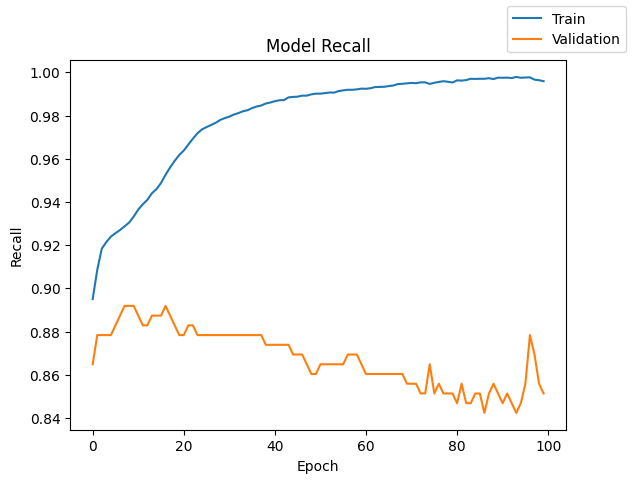

In [113]:
plot(history4,'Recall')

In [114]:
evaluation_results.loc[4] = ['Model 4 (o)', '3', '64, 32, 4', 'relu, relu, tanh', 'SGD', epochs, batch_size, history4.history["loss"][-1], history4.history["Recall"][-1], history4.history["val_loss"][-1], history4.history["val_Recall"][-1], round(end-start,2)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,optimizer,# epochs,batch size,Train_Loss,Train_Recall,Val_Loss,Val_Recall,Time (in s)
0,Model 0,1,64,relu,SGD,100,16000,0.278554,0.014640,0.273013,0.009009,5.42
1,Model 1,2,"64, 32","relu, relu",SGD,100,16000,0.243223,0.000000,0.242557,0.000000,5.54
2,Model 2,3,"64, 32, 4","relu, relu, tanh",SGD,100,32,0.031047,0.912162,0.044640,0.869369,28.86
3,Model 3 (w),3,"64, 32, 4","relu, relu, tanh",SGD,100,32,0.107541,0.967342,0.084034,0.851351,29.42
4,Model 4 (o),3,"64, 32, 4","relu, relu, tanh",SGD,100,32,0.013467,0.995897,0.100492,0.851351,51.52


In [115]:
model_4_train_perf = model_performance_classification(model_4, X_train, y_train)
model_4_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 253us/step


,Accuracy,Recall,Precision,F1 Score
0,0.99475,0.992451,0.960393,0.975806


In [116]:
model_4_val_perf = model_performance_classification(model_4,X_val,y_val)
model_4_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 314us/step


,Accuracy,Recall,Precision,F1 Score
0,0.98075,0.919852,0.901199,0.910282


Let's check the classification reports.

In [117]:
y_train_pred_4 = model_4.predict(X_train)
y_val_pred_4 = model_4.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 251us/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 299us/step


In [118]:
print("Classification Report - Train data Model_4",end="\n\n")
cr_train_model_4 = classification_report(y_train,y_train_pred_4>0.5)
print(cr_train_model_4)

Classification Report - Train data Model_4

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     15112
         1.0       0.92      0.99      0.95       888

    accuracy                           0.99     16000
   macro avg       0.96      0.99      0.98     16000
weighted avg       1.00      0.99      0.99     16000



In [119]:
print("Classification Report - Validation data Model_4",end="\n\n")
cr_val_model_4 = classification_report(y_val,y_val_pred_4>0.5)
print(cr_val_model_4)

Classification Report - Validation data Model_4

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      3778
         1.0       0.81      0.85      0.83       222

    accuracy                           0.98      4000
   macro avg       0.90      0.92      0.91      4000
weighted avg       0.98      0.98      0.98      4000



**Observations:**
* Model 4
    * The loss functions are less jagged as the dataset is more balanced.
    * Recall on the training set increased to 99% due to more data points for training, while on the validation stayed the same as Model 3, indicating similar performance on unseen data.
    * Training time increased as the set was bigger. For the rest of the models, the oversampled set will be used.

## Model 5

To introduce Regularization in our model, let's set the dropout to 50% after adding the first hidden layer. This step will randomly drop 50% of the neurons before proceeding to the next layer, reducing overfitting.

In [120]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [121]:
#Initializing the neural network.
model_5 = Sequential()
model_5.add(Dense( 64 ,activation="relu",input_dim=X_train.shape[1]))
model_5.add(Dropout(0.5))
model_5.add(Dense( 32,activation="relu"))
model_5.add(Dense( 4,activation="tanh")) 
model_5.add(Dense( 1 ,activation="sigmoid"))

In [122]:
model_5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,841 (18.91 KB)

 Trainable params: 4,841 (18.91 KB)

 Non-trainable params: 0 (0.00 B)

In [123]:
# Defining SGD as the optimizer to be used.

optimizer = tf.keras.optimizers.SGD()   

model_5.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) 


In [124]:
start = time.time()

history5 = model_5.fit(X_train_o, y_train_o, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)

end = time.time()

Epoch 1/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 641us/step - Recall: 0.8082 - loss: 0.4290 - val_Recall: 0.8829 - val_loss: 0.2934
Epoch 2/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 566us/step - Recall: 0.8737 - loss: 0.3072 - val_Recall: 0.8784 - val_loss: 0.2010
Epoch 3/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 558us/step - Recall: 0.8823 - loss: 0.2719 - val_Recall: 0.8784 - val_loss: 0.1686
Epoch 4/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 554us/step - Recall: 0.8894 - loss: 0.2454 - val_Recall: 0.8829 - val_loss: 0.1479
Epoch 5/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 564us/step - Recall: 0.8932 - loss: 0.2275 - val_Recall: 0.8829 - val_loss: 0.1260
Epoch 6/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 553us/step - Recall: 0.8999 - loss: 0.2126 - val_Recall: 0.8829 - val_loss: 0.1255
Epoch 7/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 551us/step - Recall: 0.9024 - loss: 0.2050 - val_Recall: 0.8784 - val_loss: 0.1204
Epoch 8/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 563us/step - Recall: 0.9031 - loss: 0.1967 - val_Recall: 0.8784 - v

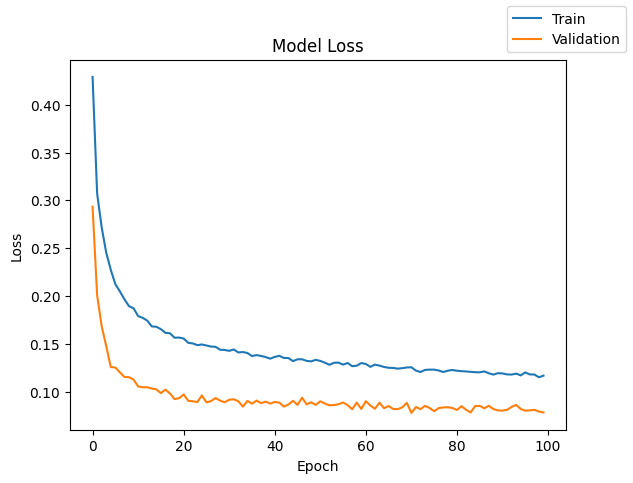

In [125]:
plot(history5,'loss')

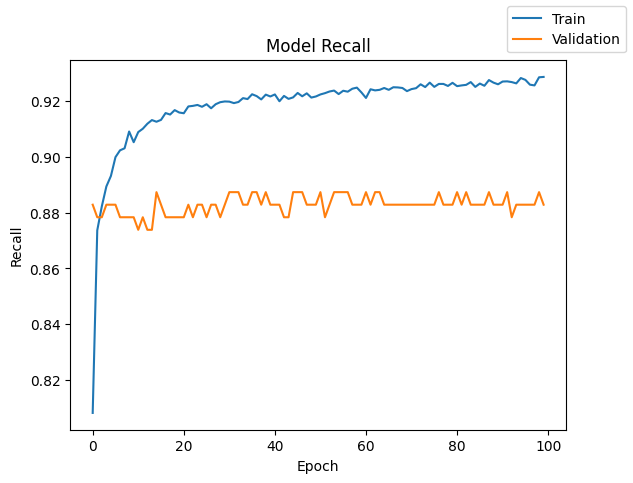

In [126]:
plot(history5,'Recall')

In [127]:
evaluation_results.loc[5] = ['Model 5 (o,d)', '3', '64, 32, 4', 'relu, relu, tanh', 'SGD', epochs, batch_size, history5.history["loss"][-1], history5.history["Recall"][-1], history5.history["val_loss"][-1], history5.history["val_Recall"][-1], round(end-start,2)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,optimizer,# epochs,batch size,Train_Loss,Train_Recall,Val_Loss,Val_Recall,Time (in s)
0,Model 0,1,64,relu,SGD,100,16000,0.278554,0.014640,0.273013,0.009009,5.42
1,Model 1,2,"64, 32","relu, relu",SGD,100,16000,0.243223,0.000000,0.242557,0.000000,5.54
2,Model 2,3,"64, 32, 4","relu, relu, tanh",SGD,100,32,0.031047,0.912162,0.044640,0.869369,28.86
3,Model 3 (w),3,"64, 32, 4","relu, relu, tanh",SGD,100,32,0.107541,0.967342,0.084034,0.851351,29.42
4,Model 4 (o),3,"64, 32, 4","relu, relu, tanh",SGD,100,32,0.013467,0.995897,0.100492,0.851351,51.52
5,"Model 5 (o,d)",3,"64, 32, 4","relu, relu, tanh",SGD,100,32,0.117062,0.928732,0.078659,0.882883,54.09


In [128]:
model_5_train_perf = model_performance_classification(model_5, X_train, y_train)
model_5_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 258us/step


,Accuracy,Recall,Precision,F1 Score
0,0.992875,0.95913,0.972166,0.965544


In [129]:
model_5_val_perf = model_performance_classification(model_5,X_val,y_val)
model_5_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 316us/step


,Accuracy,Recall,Precision,F1 Score
0,0.98975,0.939456,0.961024,0.949947


Let's check the classification reports.

In [130]:
y_train_pred_5 = model_5.predict(X_train)
y_val_pred_5 = model_5.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 268us/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 313us/step


In [131]:
print("Classification Report - Train data Model_5",end="\n\n")
cr_train_model_5 = classification_report(y_train,y_train_pred_5>0.5)
print(cr_train_model_5)

Classification Report - Train data Model_5

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     15112
         1.0       0.95      0.92      0.93       888

    accuracy                           0.99     16000
   macro avg       0.97      0.96      0.97     16000
weighted avg       0.99      0.99      0.99     16000



In [132]:
print("Classification Report - Validation data Model_5",end="\n\n")
cr_val_model_5 = classification_report(y_val,y_val_pred_5>0.5)
print(cr_val_model_5)

Classification Report - Validation data Model_5

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      3778
         1.0       0.93      0.88      0.91       222

    accuracy                           0.99      4000
   macro avg       0.96      0.94      0.95      4000
weighted avg       0.99      0.99      0.99      4000



**Observations:**
* Model 5
    * Validation loss decreased compared to Model 4.
    * Validation Recall increased in almost 3%.
    * Training time increased slightly from Model 4.

## Model 6

Keep the dropout and use new optimizer (adam).

In [133]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [134]:
#Initializing the neural network.
model_6 = Sequential()
model_6.add(Dense( 64 ,activation="relu",input_dim=X_train.shape[1]))
model_6.add(Dropout(0.5))
model_6.add(Dense( 32,activation="relu"))
model_6.add(Dense( 4,activation="tanh")) 
model_6.add(Dense( 1 ,activation="sigmoid"))

In [135]:
model_6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,841 (18.91 KB)

 Trainable params: 4,841 (18.91 KB)

 Non-trainable params: 0 (0.00 B)

In [136]:
# Defining adam as the optimizer to be used.

optimizer = tf.keras.optimizers.Adam()   

model_6.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) 


In [137]:
start = time.time()

history6 = model_6.fit(X_train_o, y_train_o, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)

end = time.time()

Epoch 1/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 703us/step - Recall: 0.8847 - loss: 0.2824 - val_Recall: 0.8649 - val_loss: 0.1105
Epoch 2/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 640us/step - Recall: 0.9051 - loss: 0.1953 - val_Recall: 0.8739 - val_loss: 0.0973
Epoch 3/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 625us/step - Recall: 0.9111 - loss: 0.1752 - val_Recall: 0.8874 - val_loss: 0.0912
Epoch 4/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 628us/step - Recall: 0.9150 - loss: 0.1650 - val_Recall: 0.8829 - val_loss: 0.0816
Epoch 5/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 619us/step - Recall: 0.9184 - loss: 0.1561 - val_Recall: 0.8784 - val_loss: 0.0892
Epoch 6/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 636us/step - Recall: 0.9199 - loss: 0.1522 - val_Recall: 0.8694 - val_loss: 0.0873
Epoch 7/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 609us/step - Recall: 0.9203 - loss: 0.1494 - val_Recall: 0.8784 - val_loss: 0.0889
Epoch 8/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 619us/step - Recall: 0.9215 - loss: 0.1470 - val_Recall: 0.8739 - v

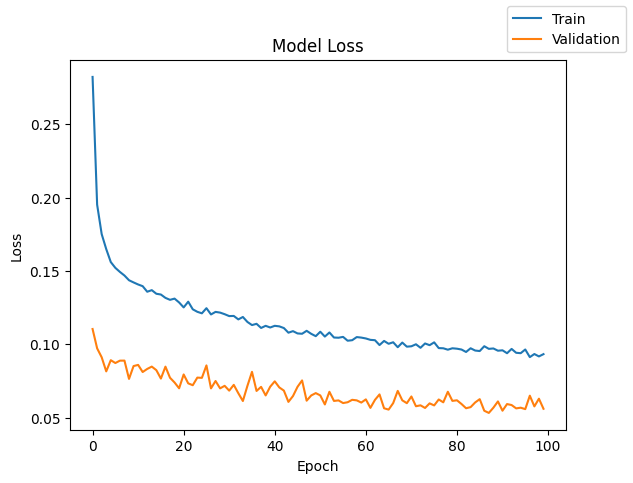

In [138]:
plot(history6,'loss')

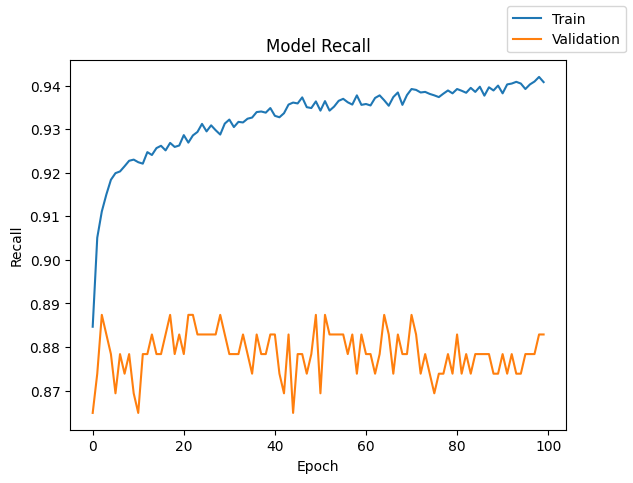

In [139]:
plot(history6,'Recall')

In [140]:
evaluation_results.loc[6] = ['Model 6 (o,d)', '3', '64, 32, 4', 'relu, relu, tanh', 'adam', epochs, batch_size, history6.history["loss"][-1], history6.history["Recall"][-1], history6.history["val_loss"][-1], history6.history["val_Recall"][-1], round(end-start,2)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,optimizer,# epochs,batch size,Train_Loss,Train_Recall,Val_Loss,Val_Recall,Time (in s)
0,Model 0,1,64,relu,SGD,100,16000,0.278554,0.014640,0.273013,0.009009,5.42
1,Model 1,2,"64, 32","relu, relu",SGD,100,16000,0.243223,0.000000,0.242557,0.000000,5.54
2,Model 2,3,"64, 32, 4","relu, relu, tanh",SGD,100,32,0.031047,0.912162,0.044640,0.869369,28.86
3,Model 3 (w),3,"64, 32, 4","relu, relu, tanh",SGD,100,32,0.107541,0.967342,0.084034,0.851351,29.42
4,Model 4 (o),3,"64, 32, 4","relu, relu, tanh",SGD,100,32,0.013467,0.995897,0.100492,0.851351,51.52
5,"Model 5 (o,d)",3,"64, 32, 4","relu, relu, tanh",SGD,100,32,0.117062,0.928732,0.078659,0.882883,54.09
6,"Model 6 (o,d)",3,"64, 32, 4","relu, relu, tanh",adam,100,32,0.093343,0.940842,0.056088,0.882883,60.00


In [141]:
model_6_train_perf = model_performance_classification(model_6, X_train, y_train)
model_6_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 252us/step


,Accuracy,Recall,Precision,F1 Score
0,0.994313,0.960951,0.984115,0.972211


In [142]:
model_6_val_perf = model_performance_classification(model_6,X_val,y_val)
model_6_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 323us/step


,Accuracy,Recall,Precision,F1 Score
0,0.992,0.940647,0.981726,0.960152


Let's check the classification reports.

In [143]:
y_train_pred_6 = model_6.predict(X_train)
y_val_pred_6 = model_6.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 250us/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 298us/step


In [144]:
print("Classification Report - Train data Model_6",end="\n\n")
cr_train_model_6 = classification_report(y_train,y_train_pred_6>0.5)
print(cr_train_model_6)

Classification Report - Train data Model_6

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     15112
         1.0       0.97      0.92      0.95       888

    accuracy                           0.99     16000
   macro avg       0.98      0.96      0.97     16000
weighted avg       0.99      0.99      0.99     16000



In [145]:
print("Classification Report - Validation data Model_6",end="\n\n")
cr_val_model_6 = classification_report(y_val,y_val_pred_6>0.5)
print(cr_val_model_6)

Classification Report - Validation data Model_6

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      3778
         1.0       0.97      0.88      0.92       222

    accuracy                           0.99      4000
   macro avg       0.98      0.94      0.96      4000
weighted avg       0.99      0.99      0.99      4000



**Observations:**
* Model 6
    * There is no significant improvement from Model 5.
    * Training time increased.

## Model 7

Let's change the learning rate for the adam optimizer.

In [146]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [147]:
#Initializing the neural network.
model_7 = Sequential()
model_7.add(Dense( 64 ,activation="relu",input_dim=X_train.shape[1]))
model_7.add(Dropout(0.5))
model_7.add(Dense( 32,activation="relu"))
model_7.add(Dense( 4,activation="tanh")) 
model_7.add(Dense( 1 ,activation="sigmoid"))

In [148]:
model_7.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,841 (18.91 KB)

 Trainable params: 4,841 (18.91 KB)

 Non-trainable params: 0 (0.00 B)

In [149]:
# Defining adam as the optimizer to be used.

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)   

model_7.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) 


In [150]:
start = time.time()

history7 = model_7.fit(X_train_o, y_train_o, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)

end = time.time()

Epoch 1/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 682us/step - Recall: 0.7674 - loss: 0.5560 - val_Recall: 0.8649 - val_loss: 0.4317
Epoch 2/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 614us/step - Recall: 0.8774 - loss: 0.3951 - val_Recall: 0.8784 - val_loss: 0.3133
Epoch 3/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 602us/step - Recall: 0.8880 - loss: 0.3268 - val_Recall: 0.8829 - val_loss: 0.2529
Epoch 4/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 607us/step - Recall: 0.8947 - loss: 0.2913 - val_Recall: 0.8649 - val_loss: 0.2116
Epoch 5/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 620us/step - Recall: 0.8952 - loss: 0.2662 - val_Recall: 0.8604 - val_loss: 0.1786
Epoch 6/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 607us/step - Recall: 0.8962 - loss: 0.2469 - val_Recall: 0.8604 - val_loss: 0.1549
Epoch 7/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 611us/step - Recall: 0.9017 - loss: 0.2321 - val_Recall: 0.8649 - val_loss: 0.1392
Epoch 8/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 618us/step - Recall: 0.9063 - loss: 0.2188 - val_Recall: 0.8694 - v

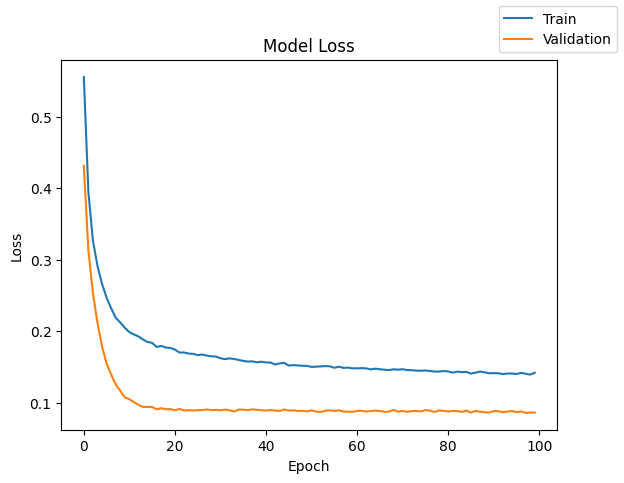

In [151]:
plot(history7,'loss')

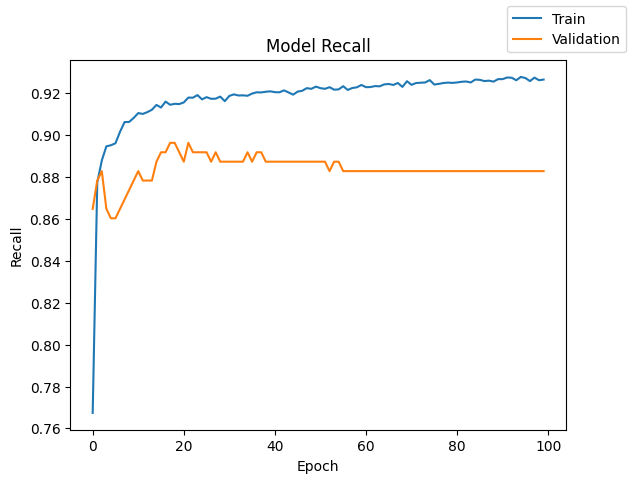

In [152]:
plot(history7,'Recall')

In [153]:
evaluation_results.loc[7] = ['Model 7 (o,d,lr)', '3', '64, 32, 4', 'relu, relu, tanh', 'adam', epochs, batch_size, history7.history["loss"][-1], history7.history["Recall"][-1], history7.history["val_loss"][-1], history7.history["val_Recall"][-1], round(end-start,2)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,optimizer,# epochs,batch size,Train_Loss,Train_Recall,Val_Loss,Val_Recall,Time (in s)
0,Model 0,1,64,relu,SGD,100,16000,0.278554,0.014640,0.273013,0.009009,5.42
1,Model 1,2,"64, 32","relu, relu",SGD,100,16000,0.243223,0.000000,0.242557,0.000000,5.54
2,Model 2,3,"64, 32, 4","relu, relu, tanh",SGD,100,32,0.031047,0.912162,0.044640,0.869369,28.86
3,Model 3 (w),3,"64, 32, 4","relu, relu, tanh",SGD,100,32,0.107541,0.967342,0.084034,0.851351,29.42
4,Model 4 (o),3,"64, 32, 4","relu, relu, tanh",SGD,100,32,0.013467,0.995897,0.100492,0.851351,51.52
5,"Model 5 (o,d)",3,"64, 32, 4","relu, relu, tanh",SGD,100,32,0.117062,0.928732,0.078659,0.882883,54.09
6,"Model 6 (o,d)",3,"64, 32, 4","relu, relu, tanh",adam,100,32,0.093343,0.940842,0.056088,0.882883,60.00
7,"Model 7 (o,d,lr)",3,"64, 32, 4","relu, relu, tanh",adam,100,32,0.141766,0.926615,0.085981,0.882883,59.70


In [154]:
model_7_train_perf = model_performance_classification(model_7, X_train, y_train)
model_7_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 254us/step


,Accuracy,Recall,Precision,F1 Score
0,0.992875,0.95754,0.973641,0.965433


In [155]:
model_7_val_perf = model_performance_classification(model_7,X_val,y_val)
model_7_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 316us/step


,Accuracy,Recall,Precision,F1 Score
0,0.99025,0.939721,0.96547,0.95218


Let's check the classification reports.

In [156]:
y_train_pred_7 = model_7.predict(X_train)
y_val_pred_7 = model_7.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 250us/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 301us/step


In [157]:
print("Classification Report - Train data Model_7",end="\n\n")
cr_train_model_7 = classification_report(y_train,y_train_pred_7>0.5)
print(cr_train_model_7)

Classification Report - Train data Model_7

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     15112
         1.0       0.95      0.92      0.93       888

    accuracy                           0.99     16000
   macro avg       0.97      0.96      0.97     16000
weighted avg       0.99      0.99      0.99     16000



In [158]:
print("Classification Report - Validation data Model_7",end="\n\n")
cr_val_model_7 = classification_report(y_val,y_val_pred_7>0.5)
print(cr_val_model_7)

Classification Report - Validation data Model_7

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      3778
         1.0       0.94      0.88      0.91       222

    accuracy                           0.99      4000
   macro avg       0.97      0.94      0.95      4000
weighted avg       0.99      0.99      0.99      4000



**Observations:**
* Model 7
    * There is no significant improvement.
    * The jarred part of the loss function has been smoothed compared to Model 6.
    * Training time decreased slightly from Model 6.

## Model 8

Let's try using the He initialization (which works better with ReLU activation) for the dense layer with ReLU activation and xavier for the tanh.

In [159]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [160]:
#Initializing the neural network.
model_8 = Sequential()
model_8.add(Dense( 64 ,activation="relu",input_dim=X_train.shape[1], kernel_initializer='he_normal'))
model_8.add(Dropout(0.5))
model_8.add(Dense( 32,activation="relu")) 
model_8.add(Dense( 4,activation="tanh", kernel_initializer='glorot_uniform'))
model_8.add(Dense( 1 ,activation="sigmoid"))

In [161]:
model_8.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,841 (18.91 KB)

 Trainable params: 4,841 (18.91 KB)

 Non-trainable params: 0 (0.00 B)

In [162]:
# Defining adam as the optimizer to be used.

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)   

model_8.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) 


In [163]:
start = time.time()

history8 = model_8.fit(X_train_o, y_train_o, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)

end = time.time()

Epoch 1/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 694us/step - Recall: 0.7137 - loss: 0.5553 - val_Recall: 0.8514 - val_loss: 0.4003
Epoch 2/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 606us/step - Recall: 0.8492 - loss: 0.3779 - val_Recall: 0.8649 - val_loss: 0.2834
Epoch 3/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 610us/step - Recall: 0.8675 - loss: 0.3226 - val_Recall: 0.8694 - val_loss: 0.2241
Epoch 4/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 612us/step - Recall: 0.8814 - loss: 0.2929 - val_Recall: 0.8784 - val_loss: 0.1804
Epoch 5/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 617us/step - Recall: 0.8883 - loss: 0.2709 - val_Recall: 0.8694 - val_loss: 0.1562
Epoch 6/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 613us/step - Recall: 0.8907 - loss: 0.2558 - val_Recall: 0.8694 - val_loss: 0.1406
Epoch 7/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 603us/step - Recall: 0.8974 - loss: 0.2399 - val_Recall: 0.8694 - val_loss: 0.1256
Epoch 8/100
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 614us/step - Recall: 0.8974 - loss: 0.2334 - val_Recall: 0.8694 - v

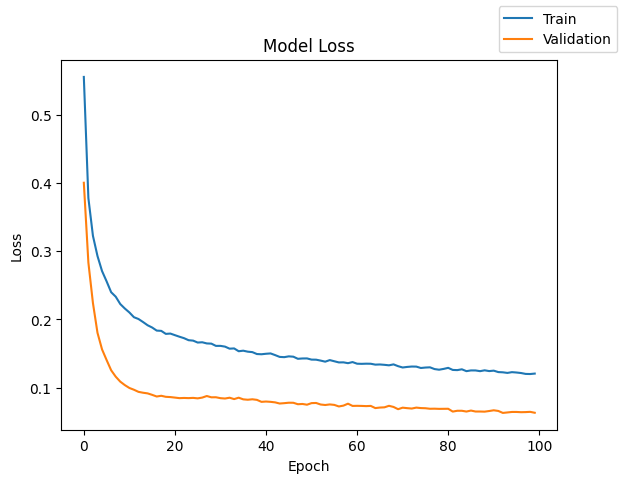

In [164]:
plot(history8,'loss')

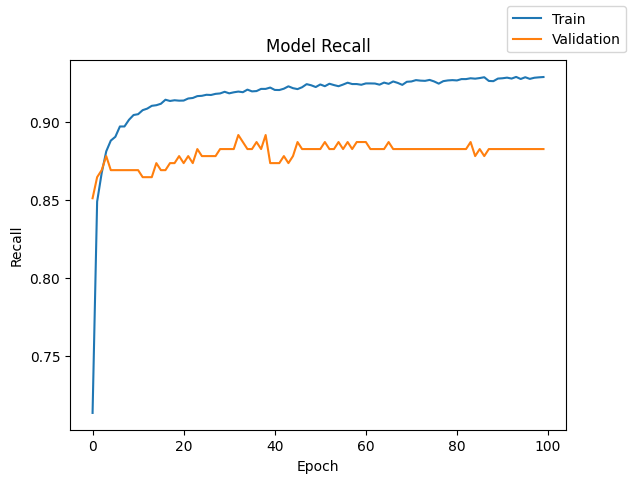

In [165]:
plot(history8,'Recall')

In [166]:
evaluation_results.loc[8] = ['Model 8 (o,d,lr,hx)', '3', '64, 32, 4', 'relu, relu, tanh', 'adam', epochs, batch_size, history8.history["loss"][-1], history8.history["Recall"][-1], history8.history["val_loss"][-1], history8.history["val_Recall"][-1], round(end-start,2)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,optimizer,# epochs,batch size,Train_Loss,Train_Recall,Val_Loss,Val_Recall,Time (in s)
0,Model 0,1,64,relu,SGD,100,16000,0.278554,0.014640,0.273013,0.009009,5.42
1,Model 1,2,"64, 32","relu, relu",SGD,100,16000,0.243223,0.000000,0.242557,0.000000,5.54
2,Model 2,3,"64, 32, 4","relu, relu, tanh",SGD,100,32,0.031047,0.912162,0.044640,0.869369,28.86
3,Model 3 (w),3,"64, 32, 4","relu, relu, tanh",SGD,100,32,0.107541,0.967342,0.084034,0.851351,29.42
4,Model 4 (o),3,"64, 32, 4","relu, relu, tanh",SGD,100,32,0.013467,0.995897,0.100492,0.851351,51.52
5,"Model 5 (o,d)",3,"64, 32, 4","relu, relu, tanh",SGD,100,32,0.117062,0.928732,0.078659,0.882883,54.09
6,"Model 6 (o,d)",3,"64, 32, 4","relu, relu, tanh",adam,100,32,0.093343,0.940842,0.056088,0.882883,60.00
7,"Model 7 (o,d,lr)",3,"64, 32, 4","relu, relu, tanh",adam,100,32,0.141766,0.926615,0.085981,0.882883,59.70
8,"Model 8 (o,d,lr,hx)",3,"64, 32, 4","relu, relu, tanh",adam,100,32,0.120723,0.929063,0.063330,0.882883,59.32


In [167]:
model_8_train_perf = model_performance_classification(model_8, X_train, y_train)
model_8_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 254us/step


,Accuracy,Recall,Precision,F1 Score
0,0.993188,0.958235,0.975935,0.966895


In [168]:
model_8_val_perf = model_performance_classification(model_8,X_val,y_val)
model_8_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 313us/step


,Accuracy,Recall,Precision,F1 Score
0,0.9915,0.940383,0.976967,0.957849


Let's check the classification reports.

In [169]:
y_train_pred_8 = model_8.predict(X_train)
y_val_pred_8 = model_8.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 251us/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 296us/step


In [170]:
print("Classification Report - Train data Model_8",end="\n\n")
cr_train_model_8 = classification_report(y_train,y_train_pred_8>0.5)
print(cr_train_model_8)

Classification Report - Train data Model_8

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     15112
         1.0       0.96      0.92      0.94       888

    accuracy                           0.99     16000
   macro avg       0.98      0.96      0.97     16000
weighted avg       0.99      0.99      0.99     16000



In [171]:
print("Classification Report - Validation data Model_8",end="\n\n")
cr_val_model_8 = classification_report(y_val,y_val_pred_8>0.5)
print(cr_val_model_8)

Classification Report - Validation data Model_8

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      3778
         1.0       0.96      0.88      0.92       222

    accuracy                           0.99      4000
   macro avg       0.98      0.94      0.96      4000
weighted avg       0.99      0.99      0.99      4000



**Observations:**
* Model 8
    * There is no significant improvement.
    * As the model is not complex and the dataset is not too big, it was not expected that there would be a significant jump in performance.

# **Model Performance Comparison and Final Model Selection**

Now, in order to select the final model, we will compare the performances of all the models for the training and validation sets.

In [172]:
# Training performance comparison.
models_train_comp_df = pd.concat(
    [   model_0_train_perf.T,
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
        model_5_train_perf.T,
        model_6_train_perf.T,
        model_7_train_perf.T,
        model_8_train_perf.T], axis=1,)
models_train_comp_df.columns = [
    "Model 0",
    "Model 1",
    "Model 2",
    "Model 3",
    "Model 4",
    "Model 5",
    "Model 6",
    "Model 7",
    "Model 8"]
print("Training set performance comparison:")
models_train_comp_df

Training set performance comparison:


,Model 0,Model 1,Model 2,Model 3,Model 4,Model 5,Model 6,Model 7,Model 8
Accuracy,0.944688,0.944500,0.995000,0.994687,0.994750,0.992875,0.994313,0.992875,0.993188
Recall,0.506989,0.500000,0.957075,0.974929,0.992451,0.959130,0.960951,0.957540,0.958235
Precision,0.755226,0.472250,0.995046,0.974426,0.960393,0.972166,0.984115,0.973641,0.975935
F1 Score,0.500037,0.485729,0.975206,0.974677,0.975806,0.965544,0.972211,0.965433,0.966895


**Validation Performance Comparison**

In [173]:
# Validation performance comparison
models_val_comp_df = pd.concat(
    [   model_0_val_perf.T,
        model_1_val_perf.T,
        model_2_val_perf.T,
        model_3_val_perf.T,
        model_4_val_perf.T,
        model_5_val_perf.T,
        model_6_val_perf.T,
        model_7_val_perf.T,
        model_8_val_perf.T], axis=1,)
models_val_comp_df.columns = [
    "Model 0",
    "Model 1",
    "Model 2",
    "Model 3",
    "Model 4",
    "Model 5",
    "Model 6",
    "Model 7",
    "Model 8"]
print("Validation set performance comparison:")
models_val_comp_df

Validation set performance comparison:


,Model 0,Model 1,Model 2,Model 3,Model 4,Model 5,Model 6,Model 7,Model 8
Accuracy,0.944750,0.944500,0.991000,0.984750,0.980750,0.989750,0.992000,0.990250,0.991500
Recall,0.504372,0.500000,0.933758,0.921970,0.919852,0.939456,0.940647,0.939721,0.940383
Precision,0.805813,0.472250,0.978684,0.931122,0.901199,0.961024,0.981726,0.965470,0.976967
F1 Score,0.494677,0.485729,0.954971,0.926490,0.910282,0.949947,0.960152,0.952180,0.957849


### Model selection:

* Models 5, 6, 7 and 8 show the best recalls for validation (around 94%), and good generalization compared to training data.
* **Model 5** will be chosen as additional modifications didn't yielded significant improvements.

In [174]:
best_model = model_5

Now, let's check the performance of the final model on the test set.

In [175]:
# Test set performance for the best model.
best_model_test_perf = model_performance_classification(best_model,X_test,y_test)
best_model_test_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 450us/step


,Accuracy,Recall,Precision,F1 Score
0,0.9878,0.936855,0.947311,0.942012


In [176]:
y_test_pred_best = best_model.predict(X_test)

cr_test_best_model = classification_report(y_test, y_test_pred_best>0.5)
print(cr_test_best_model)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 331us/step
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      4718
         1.0       0.90      0.88      0.89       282

    accuracy                           0.99      5000
   macro avg       0.95      0.94      0.94      5000
weighted avg       0.99      0.99      0.99      5000



### Predicting on single data points

In [177]:
# choosing 3 data points
equipment1_details = X_test[62:63, :]
equipment2_details = X_test[134:135, :]
equipment3_details = X_test[268:269, :]

# making a prediction
result1_prediction = best_model.predict(equipment1_details)
result2_prediction = best_model.predict(equipment2_details)
result3_prediction = best_model.predict(equipment3_details)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [178]:
def print_results(prediction, equipment_name):
    # Determine the label "Ok" for predictions less than 0.3 (for ilustration only), "Check" if between 0.3 and 0.5, "Fail" for more than 0.5.
    if prediction[0] <= 0.3:
        label = "Ok"
    elif 0.3 < prediction[0] <= 0.5:
        label = "Check"
    else:
        label = "Fail"

    
    print(f"{equipment_name} results:")
    print(f"  Prediction: {label}", prediction)
   

print_results(result1_prediction, "Equipment 1")
print_results(result2_prediction, "Equipment 2")
print_results(result3_prediction, "Equipment 3")

Equipment 1 results:
  Prediction: Ok [[0.29658946]]
Equipment 2 results:
  Prediction: Check [[0.32180253]]
Equipment 3 results:
  Prediction: Fail [[0.9998134]]


# **Actionable Insights and Recommendations**

### Actionable Insights

Regarding the dataset:

* There is no information regarding of what each variable really represents, and that makes very difficult to have a good understanding of the data.  For example the true effect of significant correlations, or identify key features. Having a better idea of what each variable is may improve model design.
* Both datasets are highly imbalanced, but keep same proportion, indicating equipment failure is not that common. Using oversampling techniques in the train data was prefered over adjusting weights due to the extra amount of data points generated. 

Regarding model building:

* The most significant improvements from the base and initial models were setting the batch size to 32 and adding an additional hidden leyer of 4 neurons with `tanh` activation.
* Adjusting weights and using oversampled data gave similar Validation recall scores, showing it was safe to continue using the oversampled set for future adjustments and improvements.
* Models 5 to 8 had very similar performance. Model 5 was selected as best model because had the least amount of changes and validation recall did't change significantly with futher adjustments.

Regarding model's performance:

* The model shows a very high recall score of almost 94 in the test data, couple with high socres in precision, F1 and accuracy.  This means that it will identify equipment failure even when the occurrences are low, and reduced number of false negatives (equipment fail but no detected).


### Recommendations

* Predictive maintenance's objective is to predict when an equipment will possibly fail, and that is usually by analyzing trends in key indicators, here the importance of having a good understanding of the different variables used.  As the output of the model is a prediction of the label for the equipment (Failure/No Failure), the probability for this classification can be used to design a better predictive and preventive maintenance program for the company.
* As seen on the `Predicting on single data points` example, a range of probabilities between 30 and 50% (a better range should be established by a qualified maintenance expert), could be used to issue a warning for inspection of equipment, to monitor and prevent a potential failure. This because the model is identifying that although there is no "real failure", the combination and trend of the variables are reaching what can be considered a "critical threshold" before failure. 

<font size=6 color='blue'>Power Ahead</font>
___

Disclaimer: this notebook uses some of the code and structure from: INN_ReneWind_Main_Project_LowCode_Notebook.ipynb, Oversampling_and_undersampling_Notebook.ipynb, MLS_1_Credit_Card_Fraud_Detection_INN_Notebook.ipynb, Week_1_Hands_on_introduction_to_Neural_Networks_Notebook.ipynb, and Week_2_Hands_on_Optimizing_Neural_Networks_Notebook.ipynb; and some AI generated recommendations (for code) from Goggle Colab.